# GEOS time-series comparison

Compares fracture attributes and DSS-style strain responses across the three thesis
simulation groups:

1. **Heterogeneous benchmark** (`heterogeneousInSitu_benchmark_frac_20 ... 23`):
   the paired new-fracture / pre-existing-fracture cases, with benchmark and
   HFTS-2-calibrated property tables
2. **KGD - fracture spacing** sweep (single fracture and $d = 8...24$ m)
3. **KGD - injection rate** sweep ($Q_0 ... Q_0/16$)

Every section has an **Attributes** subsection (shape / length / height / aperture /
pressure) and a **Strain** subsection with strain AND strain-rate waterfalls.  Where a
run exported nodal `totalDisplacement` (fiber TimeHistory or full nodeManager
collection), the displacement-based fiber is used - it captures the fracture-opening
jump exactly; the `averageStrain`-based waterfalls miss it (see the aperture-corrected
subsection).

Helper functions live in [compare_tools.py](compare_tools.py) (plotting, PVD fallback
loader) and [hdf5_tools.py](hdf5_tools.py) (HDF5 readers, fiber extraction).  Descended
from the GEOS team's `hydrofractureQueries.py`.

Thesis figures produced here are saved to `thesis_drafts/figures/` (see
`codes/README.md` for the full figure manifest).  The SPE-212370 heart-signature
replication that previously lived in this notebook was removed with the thesis case
list; see `heart_signature_GEOS/` for that work.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
from glob import glob
from matplotlib import pyplot as plt

import hdf5_tools as hdt
import mesh_tools as mt
import compare_tools as ct

cmap = plt.get_cmap("tab10")

In [3]:
BASE_FIG_DIR = "../figures/"   # created on demand (relative to notebooks/)

os.makedirs(BASE_FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save a figure into BASE_FIG_DIR; name by CONTENT, not by run."""
    path = os.path.join(BASE_FIG_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("saved:", path)

def _slug(label):
    """Filename-safe slug from a display label."""
    s = str(label)
    for ch in "$\\{}()=/":
        s = s.replace(ch, "")
    return "_".join(s.lower().split()).replace("-", "_")


# Data discovery

Scan the outputs tree once; each section below filters what it needs.  The heart-signature
runs are loaded by explicit path in their own section (their `averageStrain` files are
~2.4 GB each and are NOT needed - the displacement fiber is strictly better for them).

In [4]:
# run outputs root: working copies (default), or the packaged thesis subset
dir_path = "../outputs/"   # packaged outputs
# dir_path = "/home/bb/Codes/geos_outputs/"   # full local run directories (author machine)
all_files = glob(dir_path + "*/*/*.hdf5")

file_list_heterogeneous = []
file_list_kgd_spacing = []
file_list_kgd_injection = []

# which heterogeneous-family runs to load
keeps_heterogeneous = [
    "frac_20",
    "frac_21",
    "frac_22",
    "frac_23"
]

for file in all_files:
    if "inj" in file:
        file_list_kgd_injection.append(file)
    elif "const" in file and "rerun" in file:
        file_list_kgd_spacing.append(file)
    elif "heterogeneous" in file:
        if any(keep in file for keep in keeps_heterogeneous):
            file_list_heterogeneous.append(file)

file_list_heterogeneous.sort()
file_list_kgd_spacing.sort()
file_list_kgd_injection.sort()

raw_data_dict_heterogeneous = {}
raw_data_dict_kgd_spacing = {}
raw_data_dict_kgd_injection = {}

for file in file_list_heterogeneous:
    if "dense" in file:
        continue
    _data, _name = hdt.read_hdf5(file)
    raw_data_dict_heterogeneous[_name] = _data

for file in file_list_kgd_spacing:
    _data, _name = hdt.read_hdf5(file)
    raw_data_dict_kgd_spacing[_name] = _data

for file in file_list_kgd_injection:
    _data, _name = hdt.read_hdf5(file)
    raw_data_dict_kgd_injection[_name] = _data

print(f"heterogeneous: {len(raw_data_dict_heterogeneous)} files | "
      f"kgd spacing: {len(raw_data_dict_kgd_spacing)} | kgd injection: {len(raw_data_dict_kgd_injection)}")

heterogeneous: 12 files | kgd spacing: 12 | kgd injection: 10


# 1. Heterogeneous benchmark

`heterogeneousInSitu_*` family: layered in-situ stress, fracture plane y = 0 propagating
in x-z.  Attribute overview, then `averageStrain` waterfalls (with rate), then the fiber
(DSS) waterfalls: aperture-corrected and - for runs that exported `totalDisplacement`
(cyclic_05 onward) - the exact displacement-based version.

## 1.1 Attributes - Heterogeneous

In [5]:
atrb_dict_heterogeneous = {}

# files in a run dir that are NOT the fracture time history
skips_heterogeneous = [
    "strain",
    "displacement",
    "fiber",            # setNames-restricted displacement histories
    "hydraulicFrac",
    "naturalFrac"
]

for k in raw_data_dict_heterogeneous.keys():
    if any(skip in k for skip in skips_heterogeneous):
        continue
    _k = k.split("/")[0]
    print(f"Getting attributes for {_k}")
    _atrb = hdt.get_attributes(raw_data_dict_heterogeneous[k])
    if "elementCenter" not in _atrb:
        # not a fracture time-history file - never overwrite a good entry with it
        print(f"\tSKIPPED {k}: no elementCenter (not a fracture timeHistory)")
        continue
    atrb_dict_heterogeneous[_k] = _atrb
    print("\t", atrb_dict_heterogeneous[_k].keys())

Getting attributes for heterogeneousInSitu_benchmark_frac_20
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for heterogeneousInSitu_benchmark_frac_21
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for heterogeneousInSitu_benchmark_frac_22
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for heterogeneousInSitu_benchmark_frac_23
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])


In [6]:
# mesh definitions for shape-plot overlays; factor_dict selects the runs to compare
mesh_str_heterogeneous = '''
  <Mesh>
    <InternalMesh
      name="_NAME_"
      xCoords="{ 0, 200, 250 }"
      yCoords="{ -100, 0, 100 }"
      zCoords="{ -150, -100, 0, 100, 150 }"
      nx="{ 50, 5 }"
      ny="{ 10, 10 }"
      nz="{ 5, 25, 25, 5 }"
      xBias="{ 0, -0.6 }"
      yBias="{ 0.6, -0.6 }"
      zBias="{ 0.6, 0, 0, -0.6 }"
      cellBlockNames="{ cb1 }"
      elementTypes="{ C3D8 }"/>
  </Mesh>
'''


rename_dict_heterogeneous = {
    "heterogeneousInSitu_benchmark_frac_20": "new fracture (benchmark)",
    "heterogeneousInSitu_benchmark_frac_21": "pre-existing fracture (benchmark)",
    "heterogeneousInSitu_benchmark_frac_22": "new fracture (HFTS-2)",
    "heterogeneousInSitu_benchmark_frac_23": "pre-existing fracture (HFTS-2)",
}

# for styling
style_dict_heterogeneous = {
    "heterogeneousInSitu_benchmark_frac_20": dict(color="tab:blue",   linestyle="-",  marker="o"),
    "heterogeneousInSitu_benchmark_frac_21": dict(color="tab:orange", linestyle="-",  marker="s", shape="outline"),
    "heterogeneousInSitu_benchmark_frac_22": dict(color="tab:green",  linestyle="--", marker="^", markerfacecolor="none"),
    "heterogeneousInSitu_benchmark_frac_23": dict(color="tab:red",    linestyle="--", marker="v", markerfacecolor="none", shape="outline"),
}

mesh_dict_heterogeneous = {}
for k, v in rename_dict_heterogeneous.items():
    print(f"Creating mesh for {k}")

    mesh_str = mesh_str_heterogeneous.replace("_NAME_", v)
    mesh_parm =  mt.parse_xml(mesh_str)
    mesh_dict_heterogeneous[k] = mt.GEOSMesh(**mesh_parm[0])

Creating mesh for heterogeneousInSitu_benchmark_frac_20
Creating mesh for heterogeneousInSitu_benchmark_frac_21
Creating mesh for heterogeneousInSitu_benchmark_frac_22
Creating mesh for heterogeneousInSitu_benchmark_frac_23


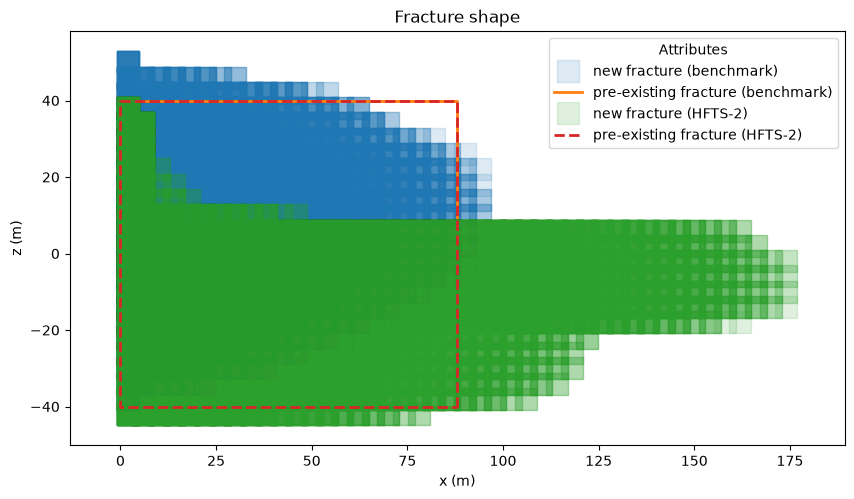

saved: ../figures/hetero_fracture_shape.png
saved: ../figures/hetero_length_evolution.png
saved: ../figures/hetero_height_evolution.png
saved: ../figures/hetero_aperture_evolution.png
saved: ../figures/hetero_pressure_evolution.png


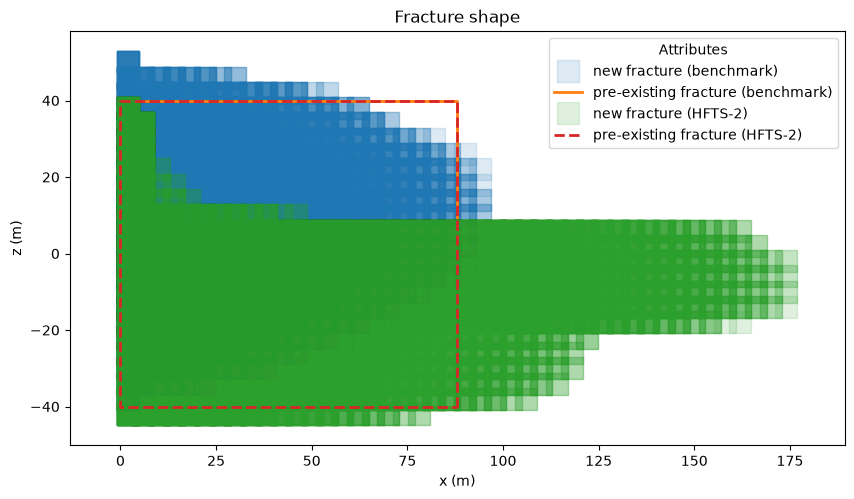

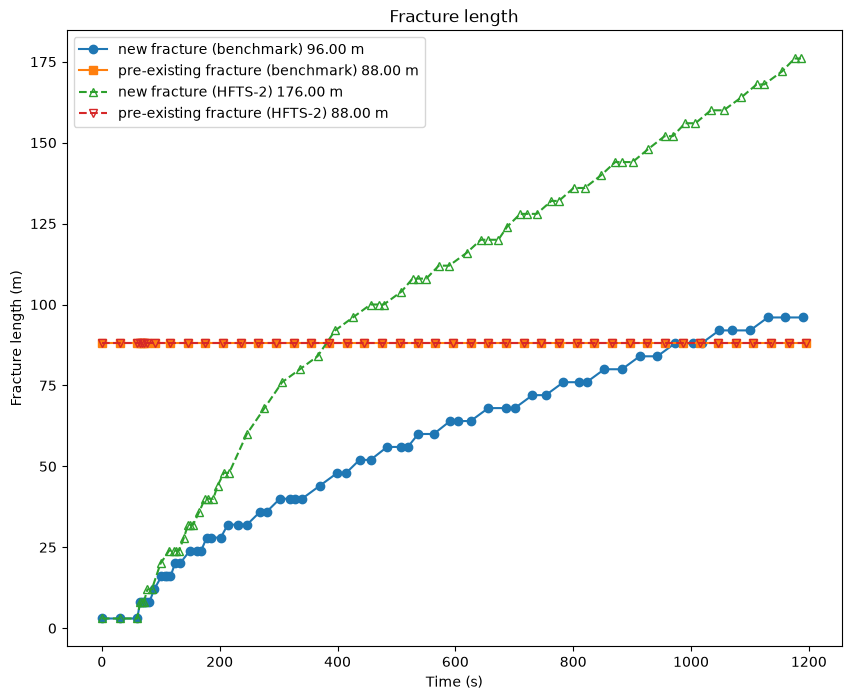

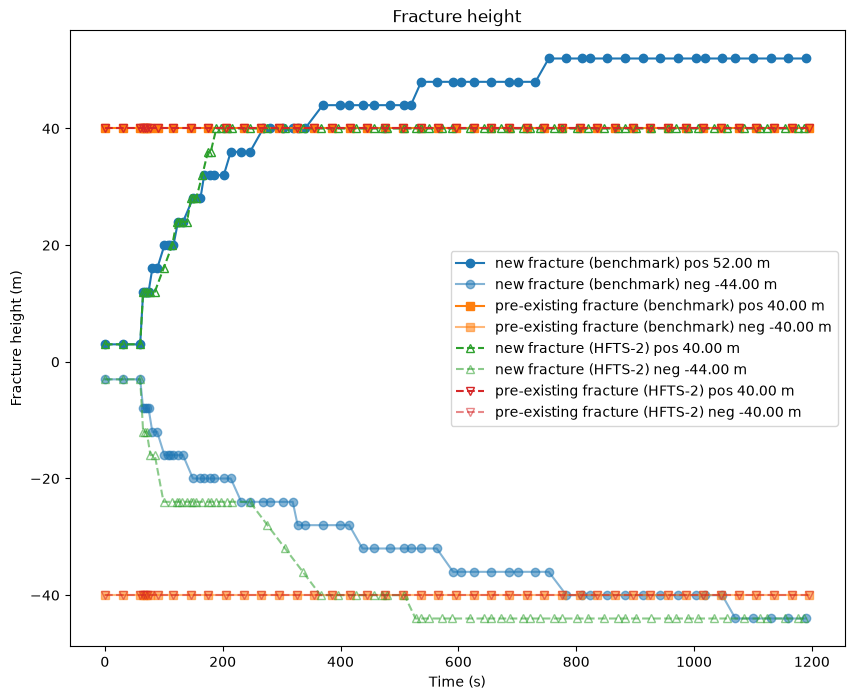

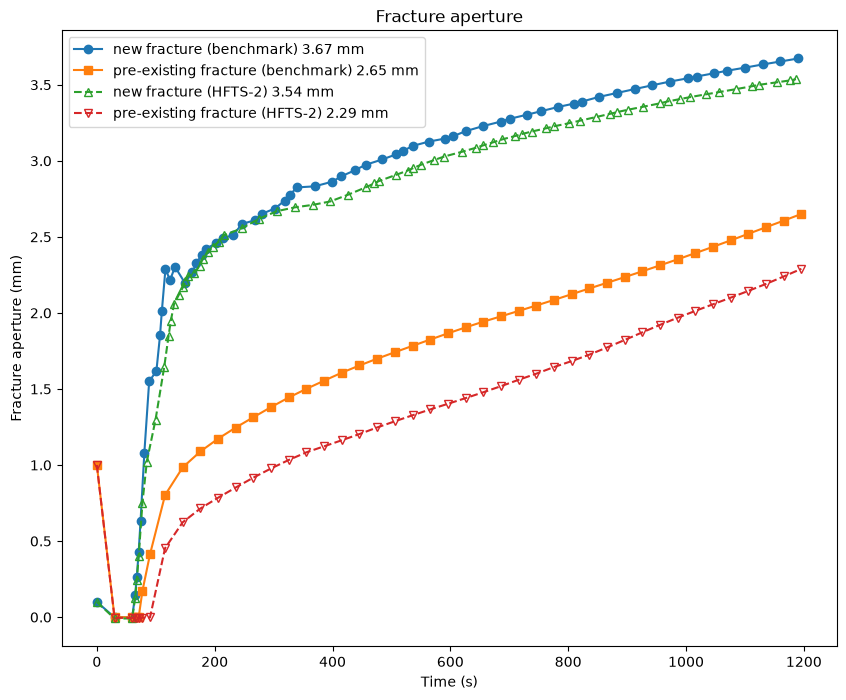

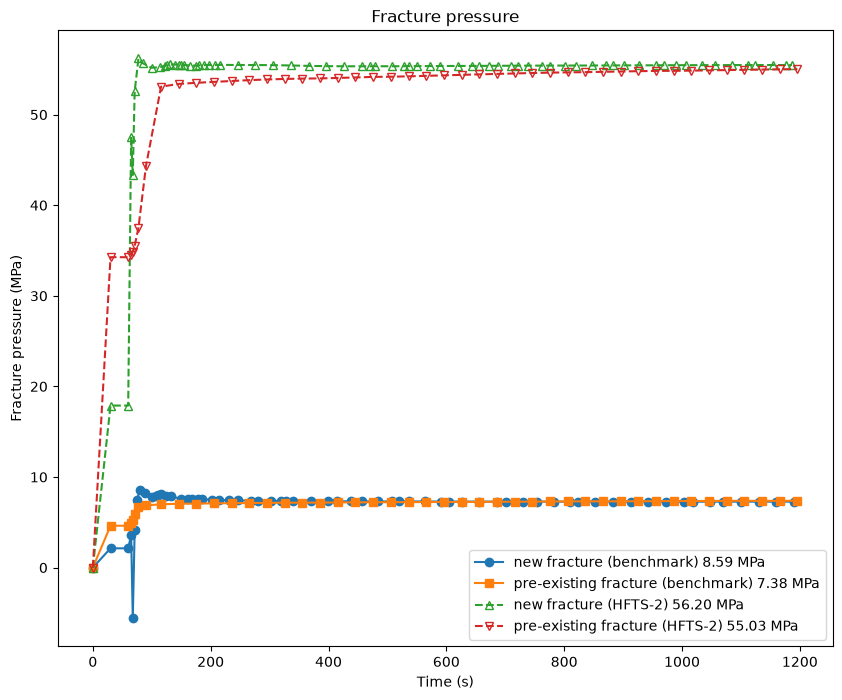

In [7]:
frac_domain = ["x", "z"]

# atrb_dict may hold more runs than we compare; plot only the factor_dict selection
atrb_plot_heterogeneous = {k: atrb_dict_heterogeneous[k] for k in rename_dict_heterogeneous}

fig_pairs_heterogeneous, proc_atrb_dict_heterogeneous = ct.plot_attributes(
    atrb_plot_heterogeneous,
    frac_domain=frac_domain,
    rename_dict=rename_dict_heterogeneous,
    frac_mesh=(None, None),   # pass a mt.plot_mesh_2d (fig, ax) to overlay the mesh
    pad=0.03,
    zoom=0.9,
    legends=True,
    style_dict=style_dict_heterogeneous,
)

for (_f, _), _n in zip(fig_pairs_heterogeneous,
                       ["hetero_fracture_shape.png", "hetero_length_evolution.png",
                        "hetero_height_evolution.png", "hetero_aperture_evolution.png",
                        "hetero_pressure_evolution.png"]):
    save_fig(_f, _n)


## 1.2 Strain - Heterogeneous

`averageStrain` volumes -> final-time slice through the fracture plane, then a fixed-x
fiber-column waterfall (strain + strain rate).

In [8]:
strain_dict_heterogeneous = {}
raw_strain_keys = ["averageStrain", "averageStrain Time", "averageStrain elementCenter"]

for k in raw_data_dict_heterogeneous.keys():
    if "strain" in k:
        _k = k.split("/")[0]
        print(f"Getting strain for {_k}")
        strain_dict_heterogeneous[_k] = hdt.get_attributes(raw_data_dict_heterogeneous[k], raw_strain_keys)
        print("\t", strain_dict_heterogeneous[_k].keys())

Getting strain for heterogeneousInSitu_benchmark_frac_20
	 dict_keys(['averageStrain', 'averageStrain Time', 'averageStrain elementCenter', 'elementCenter', 'Time'])
Getting strain for heterogeneousInSitu_benchmark_frac_21
	 dict_keys(['averageStrain', 'averageStrain Time', 'averageStrain elementCenter', 'elementCenter', 'Time'])
Getting strain for heterogeneousInSitu_benchmark_frac_22
	 dict_keys(['averageStrain', 'averageStrain Time', 'averageStrain elementCenter', 'elementCenter', 'Time'])
Getting strain for heterogeneousInSitu_benchmark_frac_23
	 dict_keys(['averageStrain', 'averageStrain Time', 'averageStrain elementCenter', 'elementCenter', 'Time'])


In [9]:
extracted_strain_dict_heterogeneous = {}

for k, v in strain_dict_heterogeneous.items():
    print(f"Extracting strain volumes for {k}")
    extracted_strain, (x_vals, y_vals, z_vals) = hdt.get_strain_volumes(
        strain_dict_heterogeneous[k]["averageStrain"],
        strain_dict_heterogeneous[k]["elementCenter"],
        comps=["xx", "yy", "zz"],
        show_msgs=False,
        as_volume=True
    )
    # (time, component, x, y, z)
    extracted_strain_dict_heterogeneous[k] = extracted_strain, (x_vals, y_vals, z_vals)
    print(f"\tExtracted strain shape: {extracted_strain.shape}")

Extracting strain volumes for heterogeneousInSitu_benchmark_frac_20
	Extracted strain shape: (64, 3, 55, 20, 60)
Extracting strain volumes for heterogeneousInSitu_benchmark_frac_21
	Extracted strain shape: (45, 3, 55, 20, 60)
Extracting strain volumes for heterogeneousInSitu_benchmark_frac_22
	Extracted strain shape: (69, 3, 55, 20, 60)
Extracting strain volumes for heterogeneousInSitu_benchmark_frac_23
	Extracted strain shape: (45, 3, 55, 20, 60)


In [10]:
clim = 1.4e-5   # strain color limit for this section

Plotting strain slice for heterogeneousInSitu_benchmark_frac_20


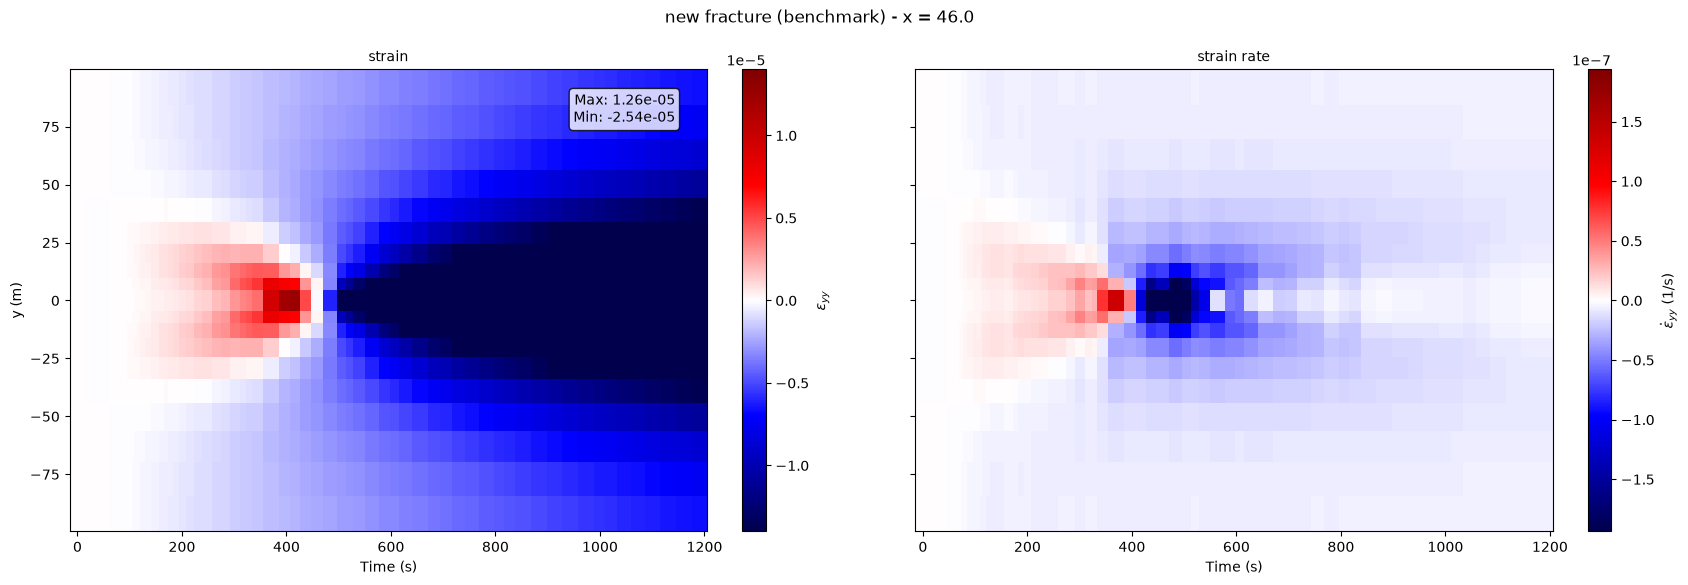

saved: ../figures/hetero_strain_waterfall_new_fracture_benchmark.png
Plotting strain slice for heterogeneousInSitu_benchmark_frac_21


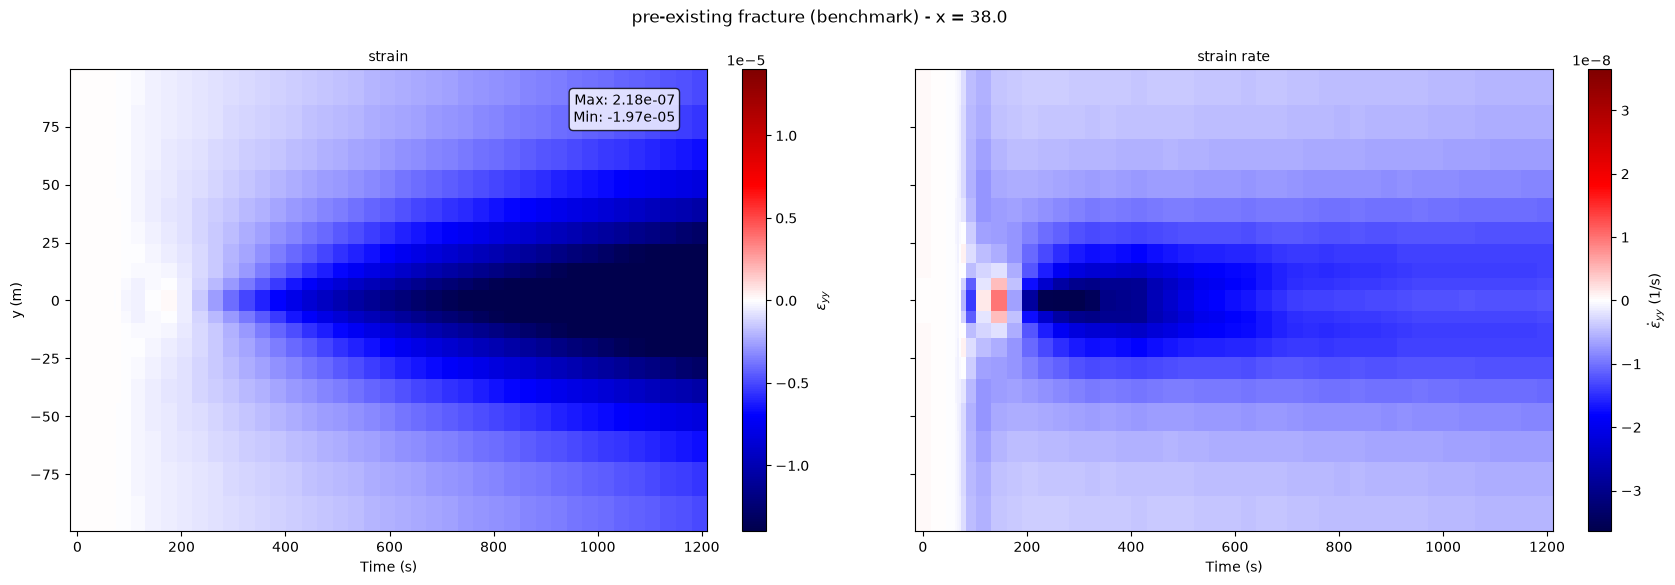

saved: ../figures/hetero_strain_waterfall_pre_existing_fracture_benchmark.png
Plotting strain slice for heterogeneousInSitu_benchmark_frac_22


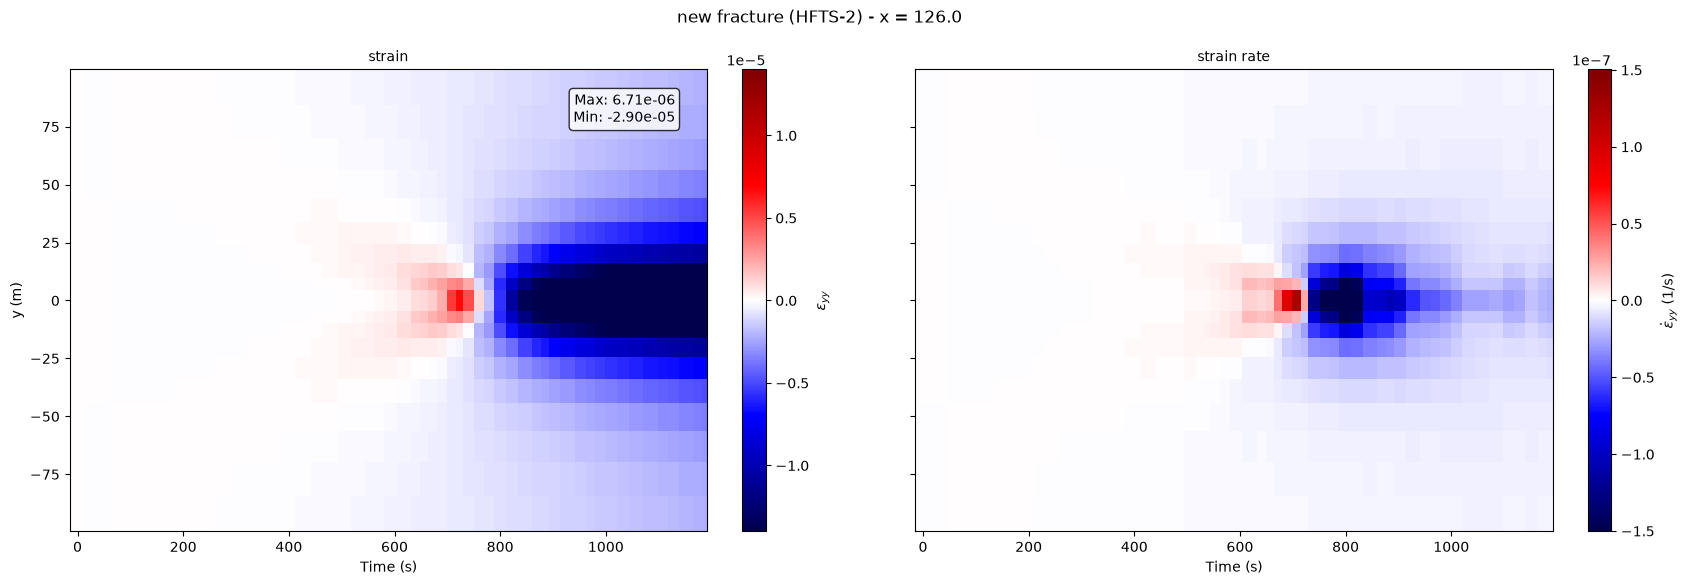

saved: ../figures/hetero_strain_waterfall_new_fracture_hfts_2.png
Plotting strain slice for heterogeneousInSitu_benchmark_frac_23


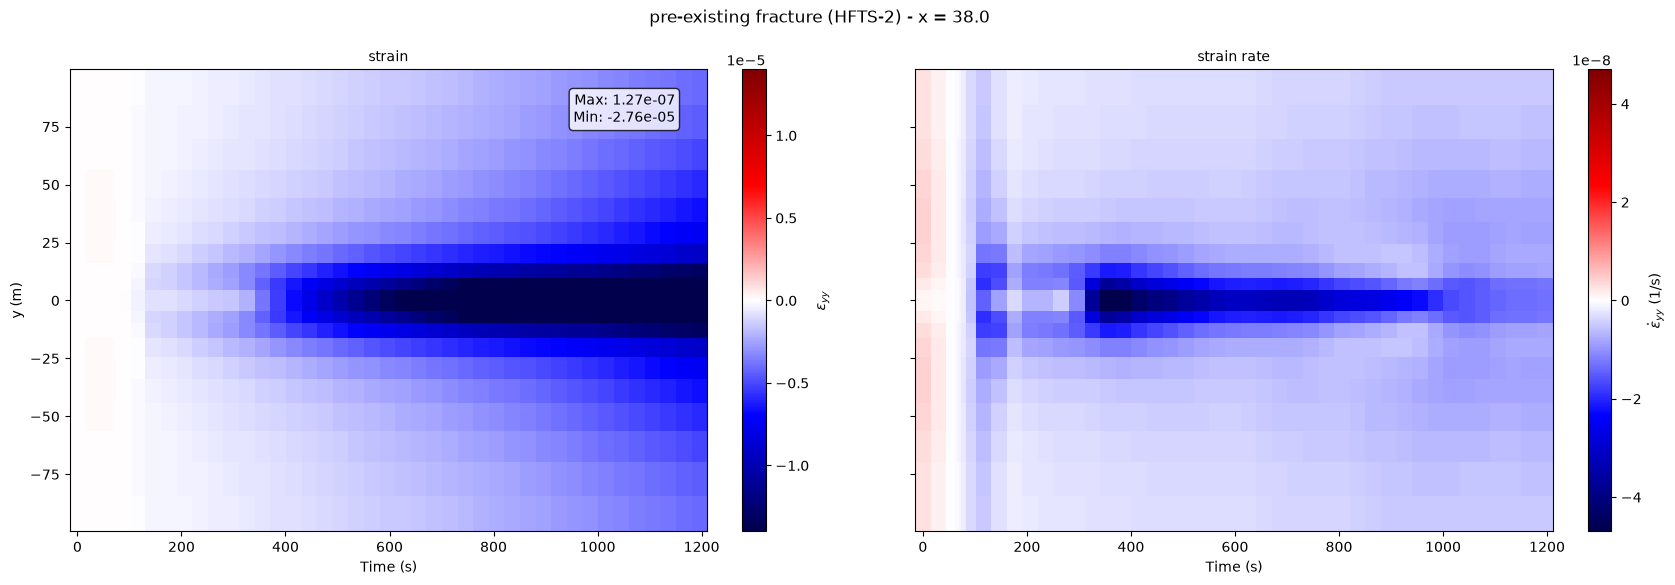

saved: ../figures/hetero_strain_waterfall_pre_existing_fracture_hfts_2.png


In [11]:
waterfall_dict_heterogeneous = {}

for k in rename_dict_heterogeneous.keys():
    print(f"Plotting strain slice for {k}")


    t_idx = -1   # last time step
    a_idx = 1    # strain component: 0=xx, 1=yy (fracture-normal), 2=zz
    extracted_strain = extracted_strain_dict_heterogeneous[k][0]
    ti, nc, nx, ny, nz = extracted_strain.shape
    x_vals, y_vals, z_vals = extracted_strain_dict_heterogeneous[k][1]
    s_idx = {0: nx, 1: ny, 2: nz}[a_idx] // 2   # mid-plane slice index
    time_axis = proc_atrb_dict_heterogeneous[k]["time"]
    fl = proc_atrb_dict_heterogeneous[k]["fracture_length"]

    # fiber column at ~final fracture length: eps_yy(t, y) + rate
    x_idx = np.argmin(np.abs(x_vals - fl[-1])) - 12
    z_idx = np.argmin(np.abs(z_vals - 0))
    waterfall = extracted_strain[:, a_idx, x_idx, :, z_idx]
    waterfall_dict_heterogeneous[k] = waterfall

    _fig, _ = ct.plot_waterfall_pair(
        waterfall, time_axis, y_vals, comp="yy", clim=clim,
        offset_label="y (m)",
        title=f"{rename_dict_heterogeneous[k]} - x = {x_vals[x_idx]:.1f}",
    )
    save_fig(_fig, f"hetero_strain_waterfall_{_slug(rename_dict_heterogeneous[k])}.png")

### Fiber (DSS) waterfall - aperture-corrected

`averageStrain` is solid-element strain only: the displacement jump across the zero-thickness
fracture belongs to no element, so a waterfall built from it shows **compression** at the core
after the fracture intercepts the fiber. A physical fiber crossing the fracture measures
`aperture / gauge_length` there (mm over ~1 m -> ~1e3 microstrain of extension) - the dominant
FDC signal (cf. SPE-212370-MS Fig 4). `hdt.get_fiber_waterfall` adds that term to the two element
rows straddling the fracture plane once an open fracture element is within `search_radius` of
the fiber position.

In [12]:
fiber_waterfall_dict_heterogeneous = {}

for k in extracted_strain_dict_heterogeneous.keys():
    vol, (x_vals, y_vals, z_vals) = extracted_strain_dict_heterogeneous[k]

    fl_open = hdt.get_open_frac_extent(
        atrb_dict_heterogeneous[k]["elementCenter"],
        atrb_dict_heterogeneous[k]["elementAperture"],
        "x",
        aperture_threshold=1e-4,   # count elements with > 0.1 mm as open
    )

    x_fiber = 0.6*fl_open   # 60% of the opened length -> intercepted well before the end

    fiber_waterfall_dict_heterogeneous[k] = hdt.get_fiber_waterfall(
        strain_vol=vol,
        coords=(x_vals, y_vals, z_vals),
        strain_time=strain_dict_heterogeneous[k]["Time"],
        frac_centers=atrb_dict_heterogeneous[k]["elementCenter"],
        frac_aperture=atrb_dict_heterogeneous[k]["elementAperture"],
        frac_time=atrb_dict_heterogeneous[k]["Time"],
        # fiber_position=(x_fiber, 0.0),   # (x, z); snaps to the nearest element centers
        fiber_position=(60, 0.0),   # (x, z); snaps to the nearest element centers
        normal_axis="y",
        # gauge_length=1.0,              # physical gauge (m) for field-comparable amplitudes
    )
    wf = fiber_waterfall_dict_heterogeneous[k]
    print(f"{k}: open length={fl_open:.1f} m, fiber @ x={x_fiber:.1f} m, gauge={wf['gauge_length']:.2f} m, "
          f"max aperture @ crossing={wf['aperture'].max()*1000:.2f} mm")

Fiber snapped to nearest element centers: requested (60, 0.0), using (58.0, -2.0).
heterogeneousInSitu_benchmark_frac_20: open length=94.0 m, fiber @ x=56.4 m, gauge=4.00 m, max aperture @ crossing=2.29 mm
Fiber snapped to nearest element centers: requested (60, 0.0), using (58.0, -2.0).
heterogeneousInSitu_benchmark_frac_21: open length=86.0 m, fiber @ x=51.6 m, gauge=4.00 m, max aperture @ crossing=1.69 mm
Fiber snapped to nearest element centers: requested (60, 0.0), using (58.0, -2.0).
heterogeneousInSitu_benchmark_frac_22: open length=170.0 m, fiber @ x=102.0 m, gauge=4.00 m, max aperture @ crossing=2.31 mm
Fiber snapped to nearest element centers: requested (60, 0.0), using (58.0, -2.0).
heterogeneousInSitu_benchmark_frac_23: open length=86.0 m, fiber @ x=51.6 m, gauge=4.00 m, max aperture @ crossing=1.43 mm


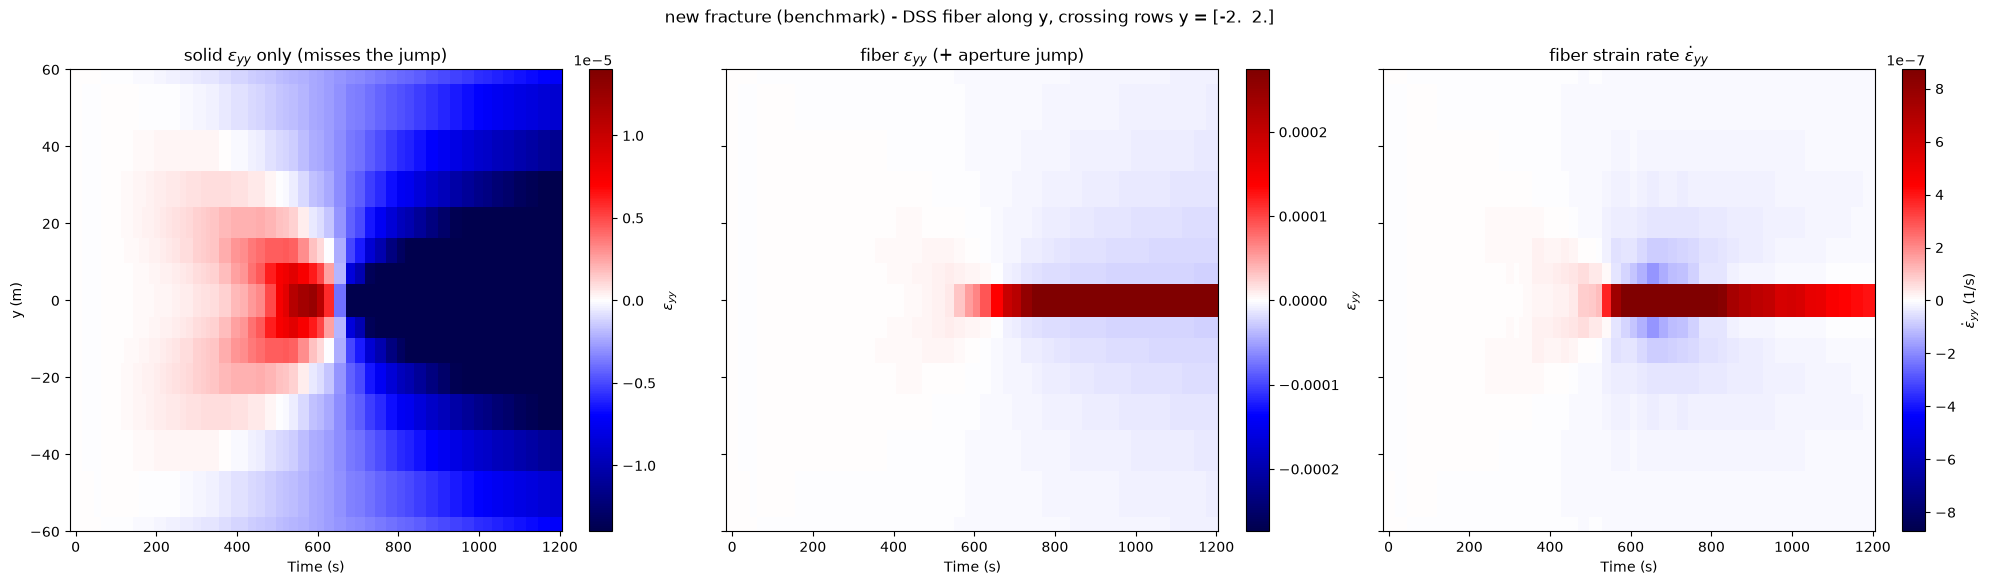

saved: ../figures/hetero_fiber_panels_new_fracture_benchmark.png


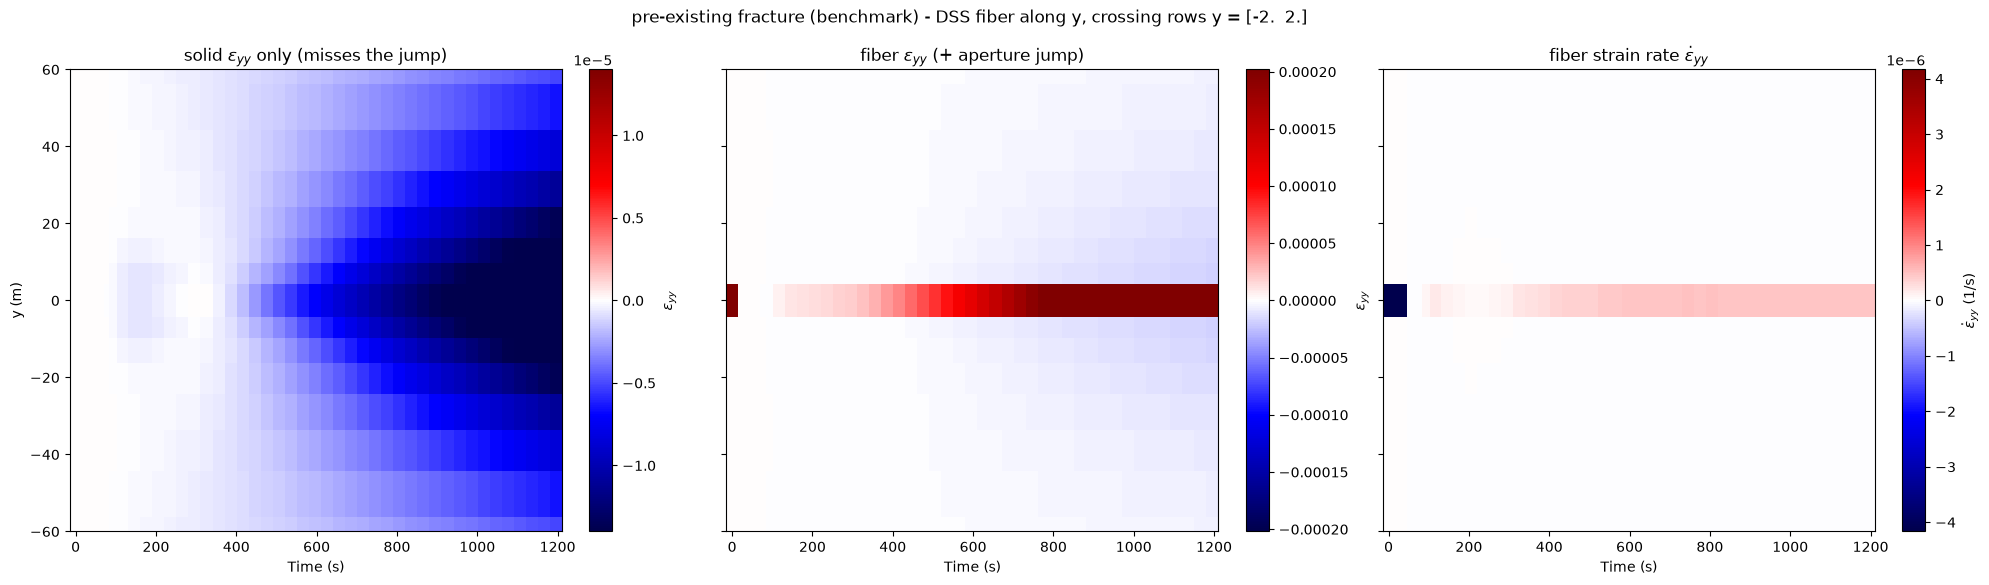

saved: ../figures/hetero_fiber_panels_pre_existing_fracture_benchmark.png


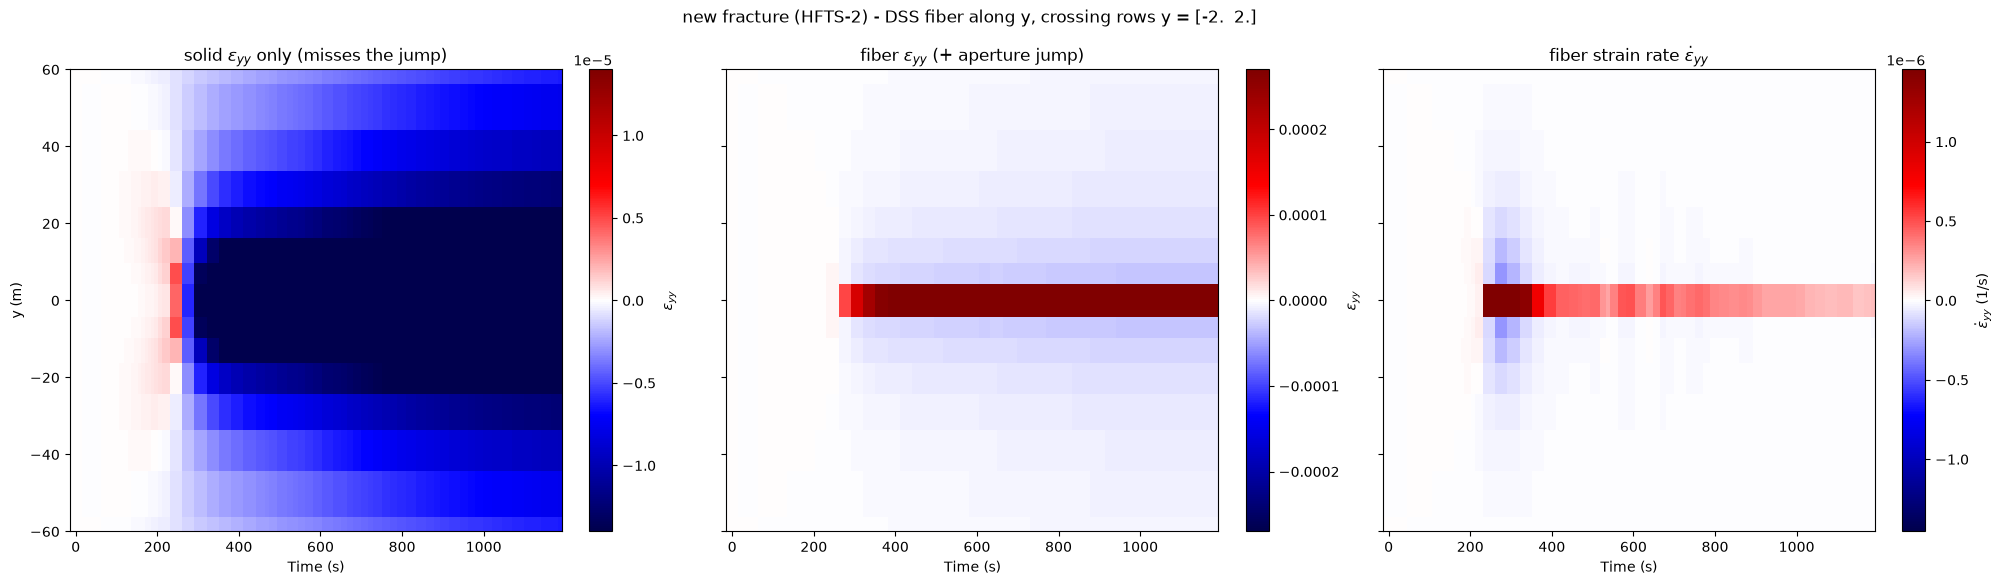

saved: ../figures/hetero_fiber_panels_new_fracture_hfts_2.png


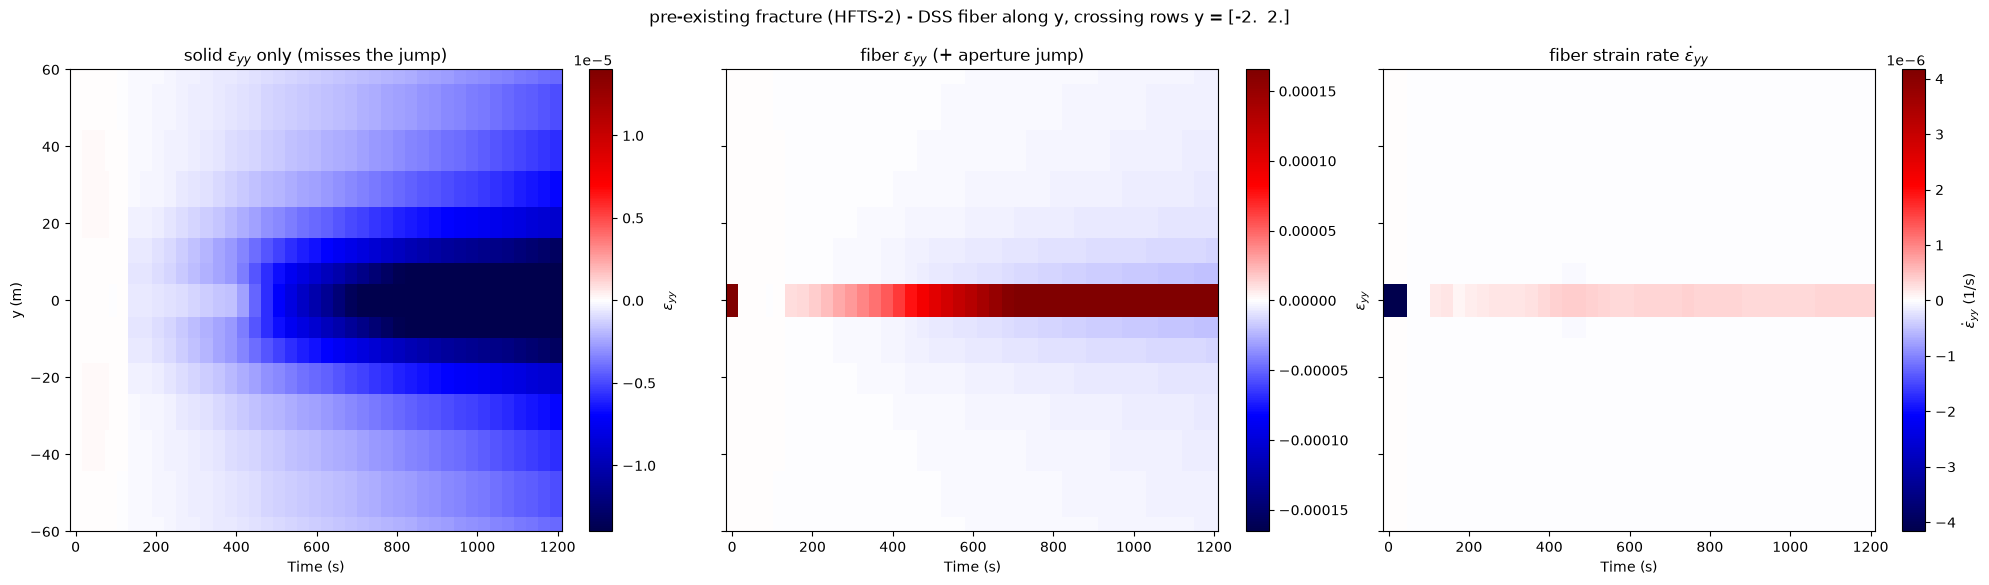

saved: ../figures/hetero_fiber_panels_pre_existing_fracture_hfts_2.png


In [13]:
fiber_panel_clims = {
    # "heterogeneousInSitu_benchmark_frac_20": 2.0e-4,
    # "heterogeneousInSitu_benchmark_frac_22": (2.0e-4, 5.0e-6),
}

for k, wf in fiber_waterfall_dict_heterogeneous.items():
    spec = fiber_panel_clims.get(k)
    clim_fiber, rate_clim = spec if isinstance(spec, (tuple, list)) else (spec, None)
    _fig, _ = ct.plot_fiber_panels(wf, clim_solid=clim, title=rename_dict_heterogeneous.get(k, k),
                                   clim_fiber=clim_fiber, rate_clim=rate_clim)
    save_fig(_fig, f"hetero_fiber_panels_{_slug(rename_dict_heterogeneous.get(k, k))}.png")

### Displacement-based fiber (exact jump)

Runs that export `heterogeneousInSitu_timeHistory_displacement.hdf5` (cyclic_05 onward) allow
computing the fiber strain directly from nodal `totalDisplacement`: `du_y/dy` between consecutive
nodes along the fiber. Differencing across the fracture plane captures the opening jump exactly,
so this is the ground truth the aperture-corrected waterfall above approximates. Runs without
the displacement file are skipped.

In [14]:
disp_fiber_dict_heterogeneous = {}

for k, wf in fiber_waterfall_dict_heterogeneous.items():
    # nodal displacement lives in either naming convention:
    #   *_timeHistory_displacement.hdf5  (whole-nodeManager collection, cyclic_05+)
    #   *_timeHistory_fiber.hdf5         (fiber nodeset collection, frac_20+;
    #                                     datasets carry the ' fiber' suffix)
    disp_key = next((rk for rk in raw_data_dict_heterogeneous.keys()
                     if rk.split("/")[0] == k
                     and ("displacement" in rk or "fiber" in rk)), None)
    if disp_key is None:
        print(f"{k}: no displacement/fiber time history (older run) - skipping")
        continue

    ds = raw_data_dict_heterogeneous[disp_key]
    keys = ds.keys()
    disp_fiber_dict_heterogeneous[k] = hdt.get_displacement_fiber_waterfall(
        node_positions=ds[next(kk for kk in keys if "ReferencePosition" in kk)],
        node_displacements=ds[next(kk for kk in keys if "totalDisplacement" in kk and "ReferencePosition" not in kk and "Time" not in kk)],
        disp_time=ds[next(kk for kk in keys if "Time" in kk)],
        fiber_position=wf["fiber_position"],   # same fiber as the aperture-corrected waterfall
        normal_axis=wf["normal_axis"],
    )
    dwf = disp_fiber_dict_heterogeneous[k]
    print(f"{k}: displacement fiber @ {dwf['fiber_position']}, "
          f"crossing gauge = {dwf['gauge_lengths'][dwf['crossing_row']]:.2f} m")

Fiber snapped to nearest node column: requested (58.0, -2.0), using (60.0, 0.0).
heterogeneousInSitu_benchmark_frac_20: displacement fiber @ (60.0, 0.0), crossing gauge = 8.00 m
Fiber snapped to nearest node column: requested (58.0, -2.0), using (60.0, 0.0).
heterogeneousInSitu_benchmark_frac_21: displacement fiber @ (60.0, 0.0), crossing gauge = 8.00 m
Fiber snapped to nearest node column: requested (58.0, -2.0), using (60.0, 0.0).
heterogeneousInSitu_benchmark_frac_22: displacement fiber @ (60.0, 0.0), crossing gauge = 8.00 m
Fiber snapped to nearest node column: requested (58.0, -2.0), using (60.0, 0.0).
heterogeneousInSitu_benchmark_frac_23: displacement fiber @ (60.0, 0.0), crossing gauge = 8.00 m


In [15]:
clim = 1.4e-5   # strain color limit for this section

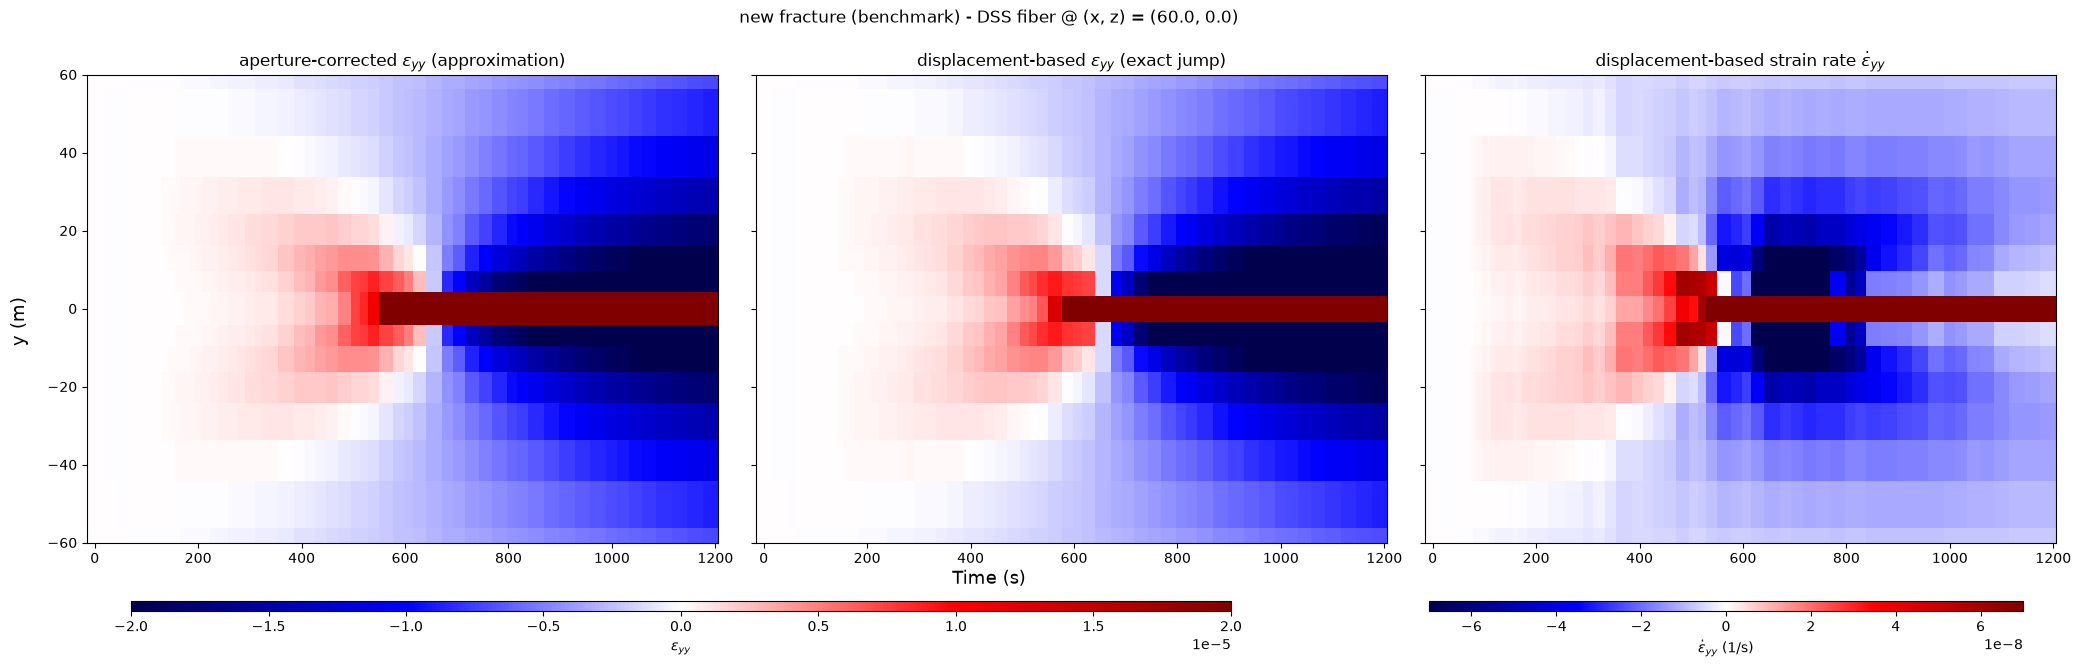

saved: ../figures/hetero_fiber_displacement_new_fracture_benchmark.png


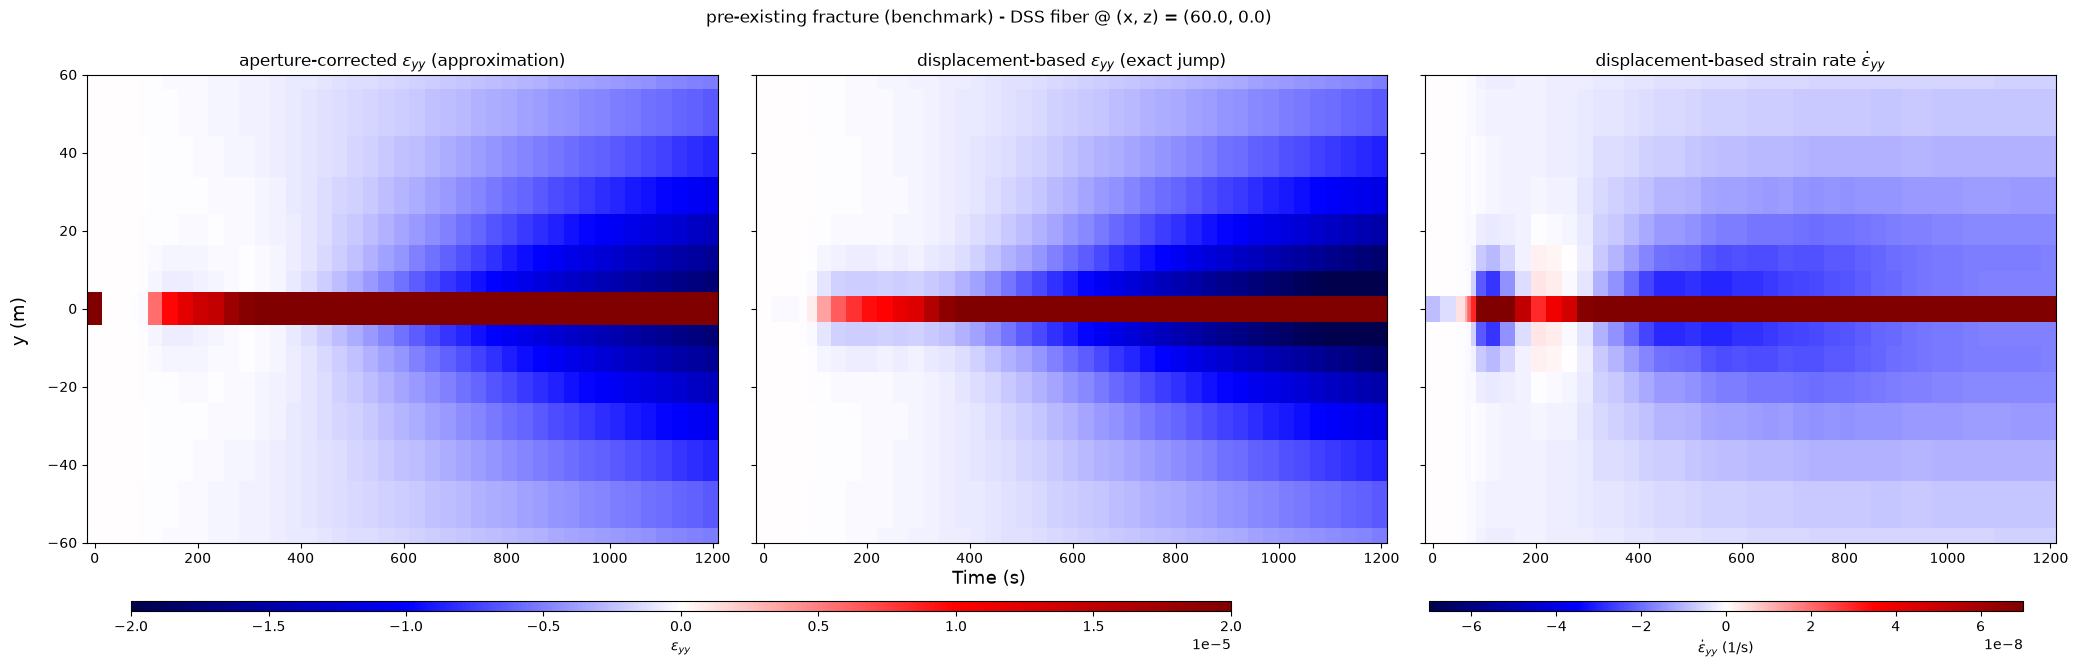

saved: ../figures/hetero_fiber_displacement_pre_existing_fracture_benchmark.png


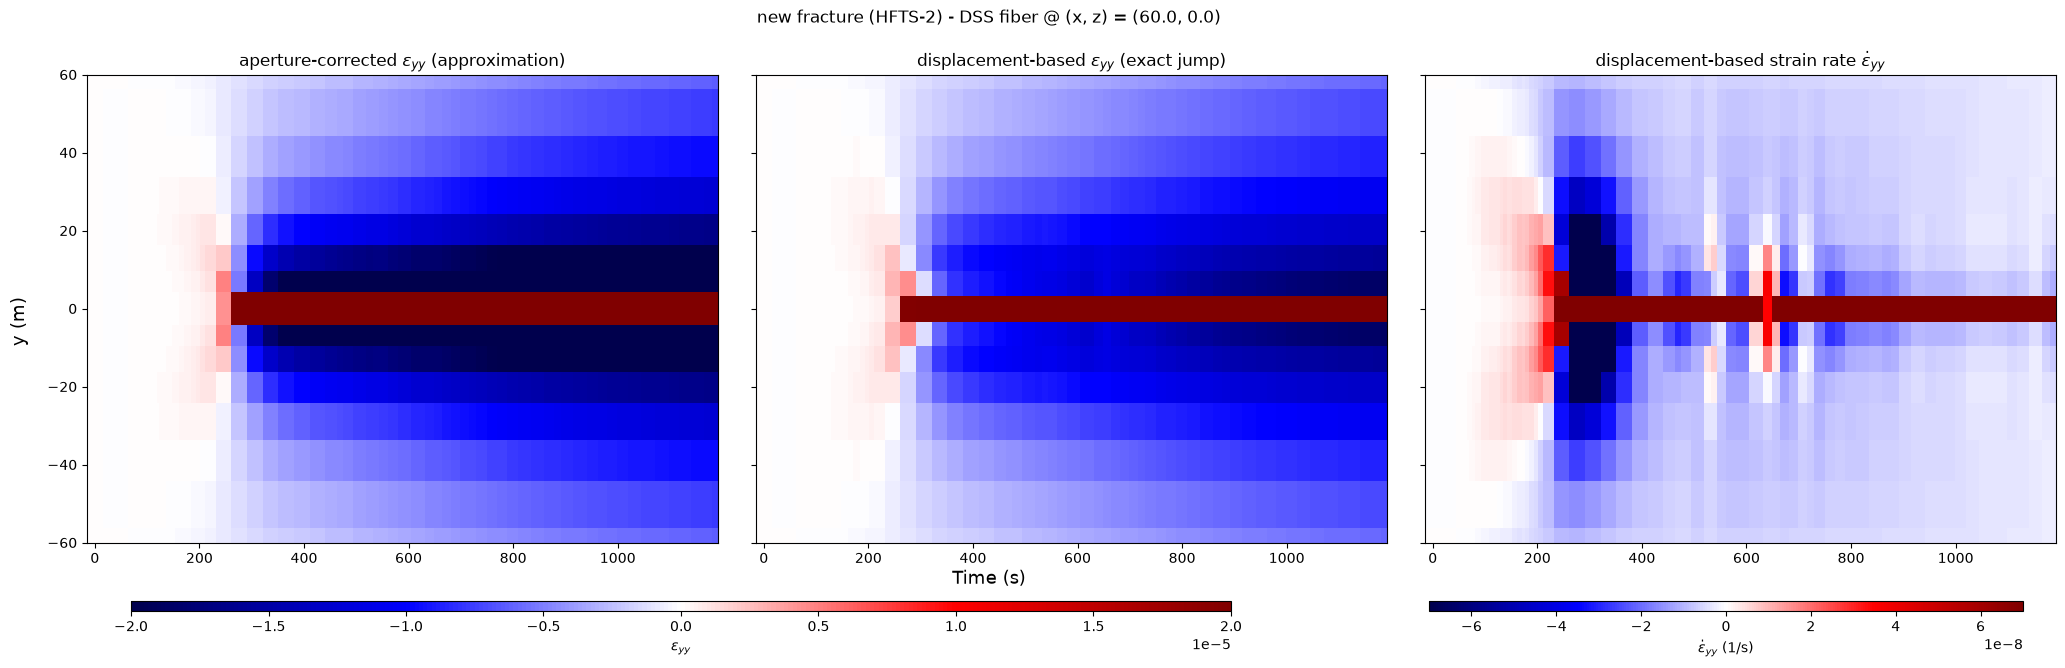

saved: ../figures/hetero_fiber_displacement_new_fracture_hfts_2.png


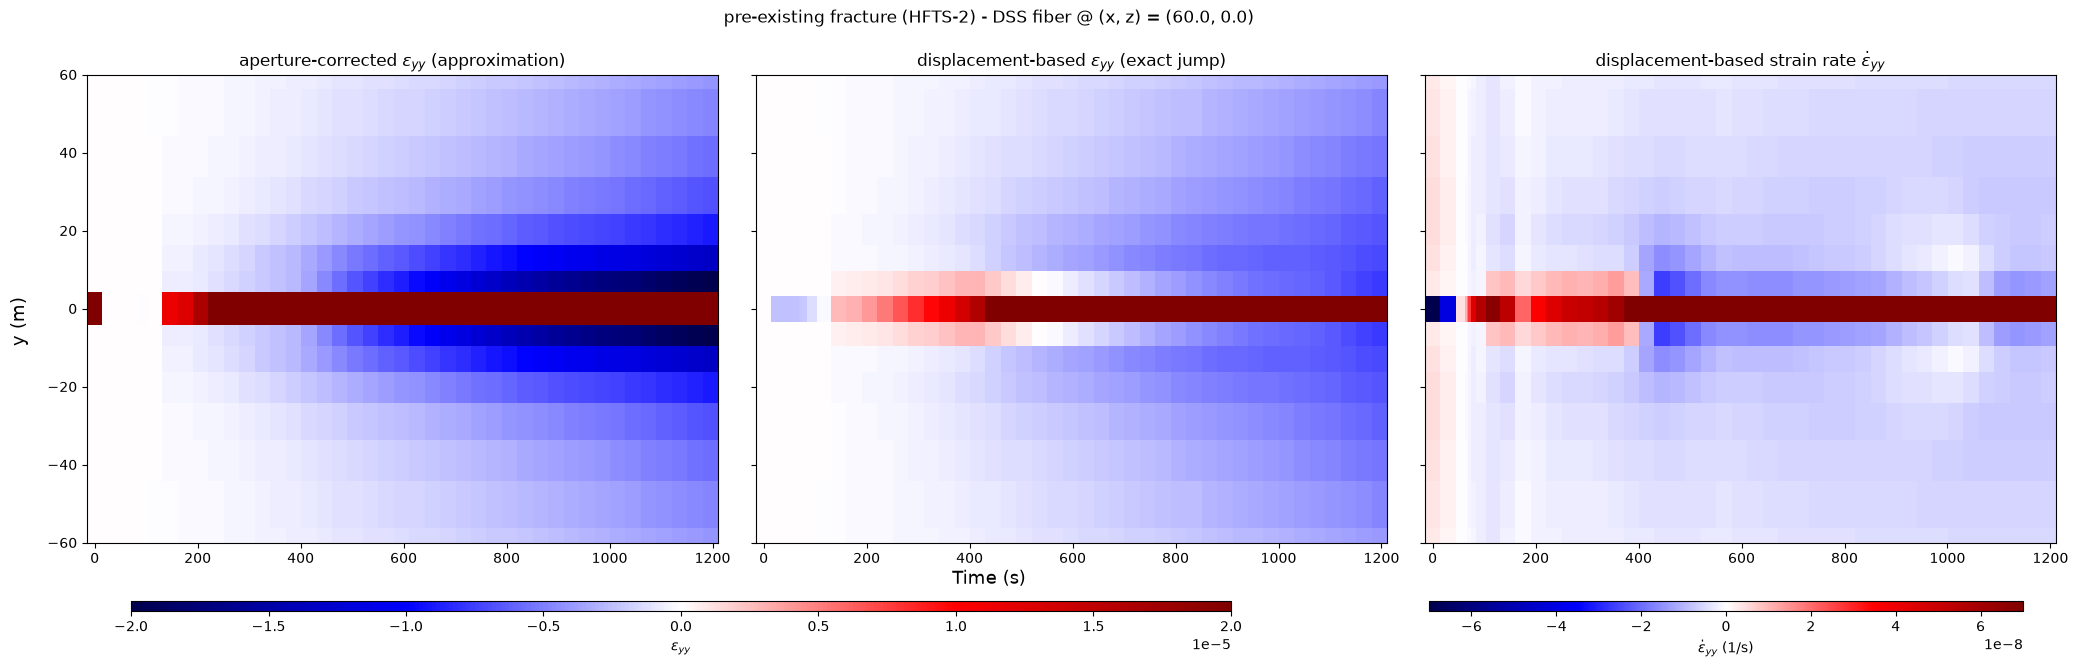

saved: ../figures/hetero_fiber_displacement_pre_existing_fracture_hfts_2.png


In [16]:
disp_fiber_clims = {
    "heterogeneousInSitu_benchmark_frac_20": (2e-5, 7e-8),
    "heterogeneousInSitu_benchmark_frac_21": (2e-5, 7e-8),
    "heterogeneousInSitu_benchmark_frac_22": (2e-5, 7e-8),
    "heterogeneousInSitu_benchmark_frac_23": (2e-5, 7e-8),
}

for k, dwf in disp_fiber_dict_heterogeneous.items():
    spec = disp_fiber_clims.get(k)
    clim, rate_clim = spec if isinstance(spec, (tuple, list)) else (spec, None)
    _fig, _ = ct.plot_fiber_vs_displacement(fiber_waterfall_dict_heterogeneous[k], dwf,
                                            title=rename_dict_heterogeneous.get(k, k),
                                            clim=clim, rate_clim=rate_clim)
    save_fig(_fig, f"hetero_fiber_displacement_{_slug(rename_dict_heterogeneous.get(k, k))}.png")

### Discriminator figures (new vs pre-existing, per property set)

The SPE-212370 contrast in one figure per property set: displacement-based fiber
strain + strain rate, new fracture beside its pre-existing twin.

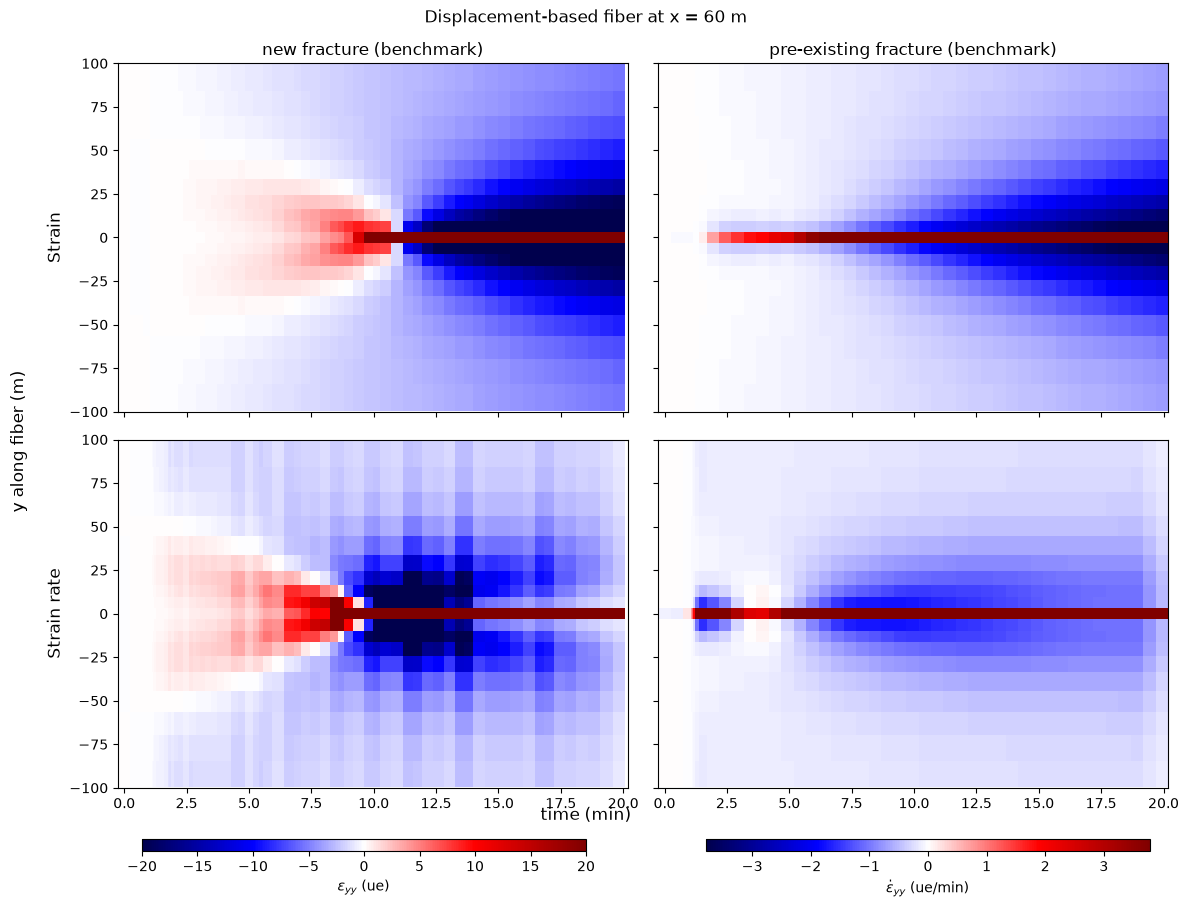

saved: ../figures/discriminator_benchmark.png


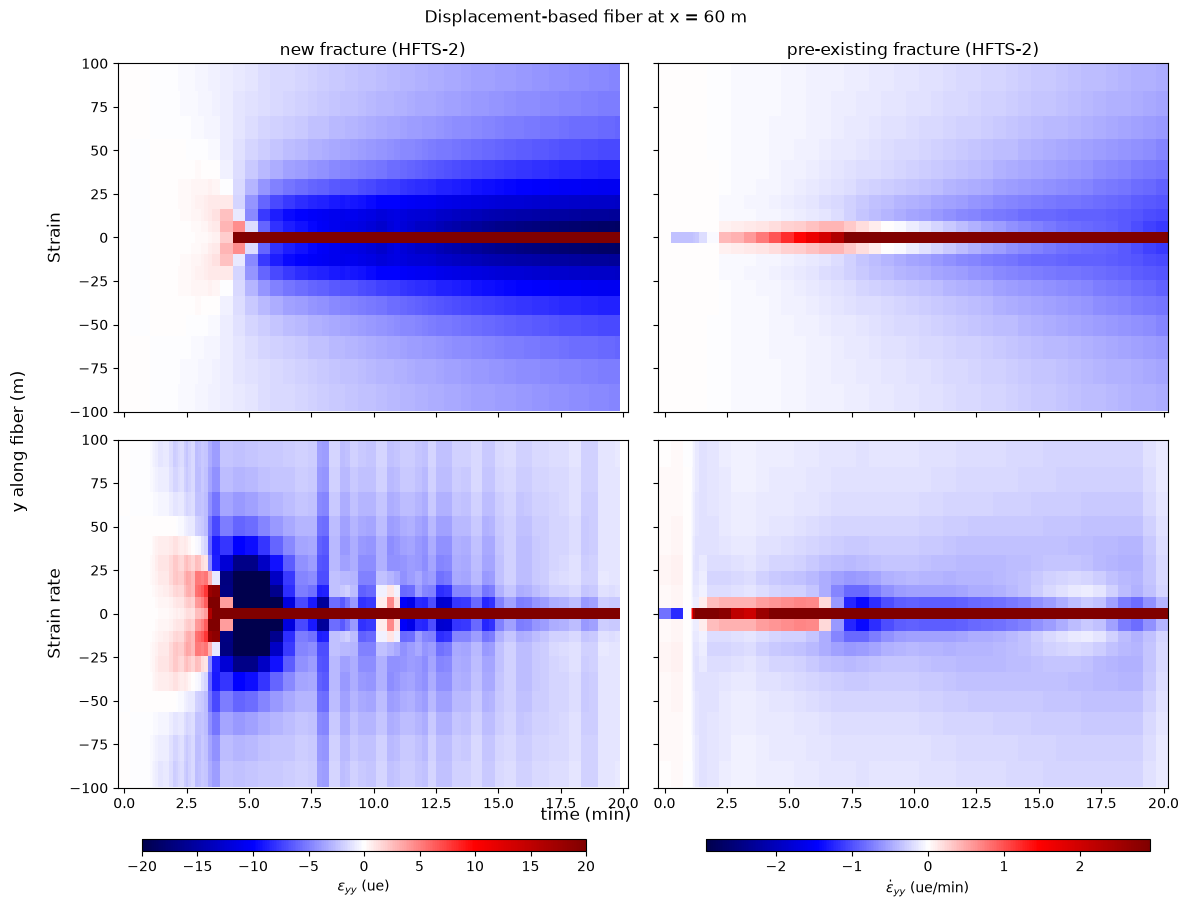

saved: ../figures/discriminator_hfts2.png


In [17]:
# side-by-side discriminators, saved by content
_pairs = {
    "discriminator_benchmark.png": ("heterogeneousInSitu_benchmark_frac_20",
                                    "heterogeneousInSitu_benchmark_frac_21"),
    "discriminator_hfts2.png":     ("heterogeneousInSitu_benchmark_frac_22",
                                    "heterogeneousInSitu_benchmark_frac_23"),
}
for _fname, (_kn, _ko) in _pairs.items():
    if _kn not in disp_fiber_dict_heterogeneous or _ko not in disp_fiber_dict_heterogeneous:
        print(f"{_fname}: runs not loaded - skipping")
        continue
    _fig, _ = ct.plot_displacement_fiber_grid(
        {rename_dict_heterogeneous[_kn]: disp_fiber_dict_heterogeneous[_kn],
         rename_dict_heterogeneous[_ko]: disp_fiber_dict_heterogeneous[_ko]},
        monitor_x=60.0, smooth_frames=3, clim=2e-5)   # shared strain scale (see disp_fiber_clims note)
    save_fig(_fig, _fname)

saved: ../figures/hetero_core_amplitudes.png


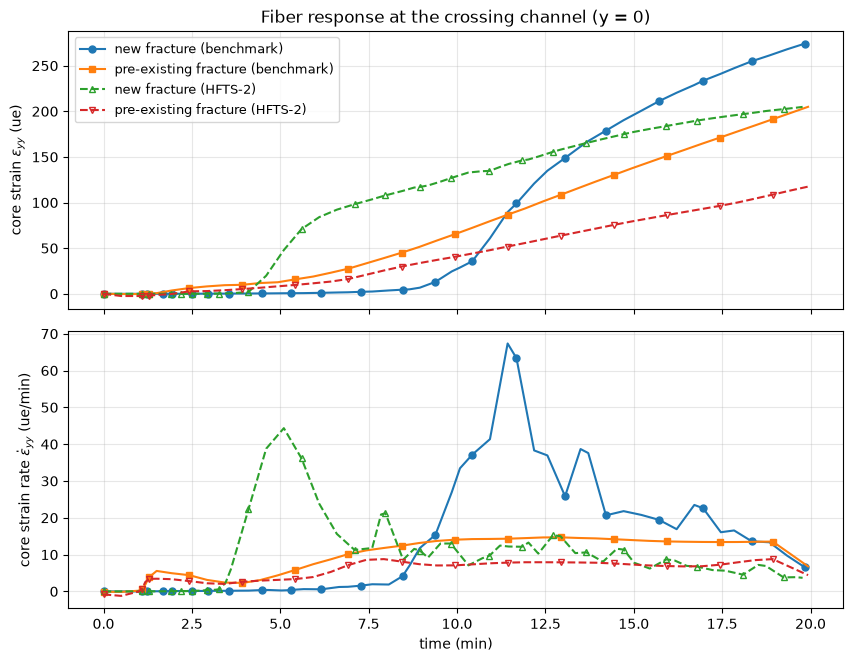

In [18]:
# Core-channel amplitude comparison: strain and strain rate at the fiber
# channel that crosses the fracture plane (y = 0), for all four interaction
# cases.  Backs the amplitude discriminator quantitatively: the waterfall
# color scales make relative amplitudes hard to judge, a line plot does not.
_style_core = {
    "heterogeneousInSitu_benchmark_frac_20": dict(color="tab:blue",   ls="-",  marker="o"),
    "heterogeneousInSitu_benchmark_frac_21": dict(color="tab:orange", ls="-",  marker="s"),
    "heterogeneousInSitu_benchmark_frac_22": dict(color="tab:green",  ls="--", marker="^", mfc="none"),
    "heterogeneousInSitu_benchmark_frac_23": dict(color="tab:red",    ls="--", marker="v", mfc="none"),
}
_fig, (_ax1, _ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True,
                                  gridspec_kw=dict(hspace=0.08))
for k, dwf in disp_fiber_dict_heterogeneous.items():
    tm = np.asarray(dwf["time"]).ravel()/60.0
    core = dwf["fiber"][:, dwf["crossing_row"]]*1e6          # exact-jump channel
    rate = ct.strain_rate(dwf["fiber"], tm, smooth_frames=3)[:, dwf["crossing_row"]]*1e6
    _ax1.plot(tm, core, markevery=3, ms=5, label=rename_dict_heterogeneous[k], **_style_core[k])
    _ax2.plot(tm, rate, markevery=3, ms=5, label=rename_dict_heterogeneous[k], **_style_core[k])
_ax1.set_ylabel(r"core strain $\epsilon_{yy}$ ($\mu\varepsilon$)")
_ax2.set_ylabel(r"core strain rate $\dot{\epsilon}_{yy}$ ($\mu\varepsilon$/min)")
_ax2.set_xlabel("time (min)")
_ax1.legend(fontsize=9)
_ax1.grid(alpha=0.3); _ax2.grid(alpha=0.3)
_ax1.set_title("Fiber response at the crossing channel (y = 0)")
save_fig(_fig, "hetero_core_amplitudes.png")


# 2. KGD - fracture spacing

2D KGD toughness-dominated cases: fracture plane x = 0, propagating along y.
The monitored line runs along x, crossing the fracture(s) at a fixed y near the
final length.

## 2.1 Attributes - KGD spacing

In [19]:
atrb_dict_kgd_spacing = {}

for k in raw_data_dict_kgd_spacing.keys():
    if "28" in k:      # excluded run
        continue
    if "strain" in k:
        continue
    _k = k.split("/")[0]
    print(f"Getting attributes for {_k}")
    atrb_dict_kgd_spacing[_k] = hdt.get_attributes(raw_data_dict_kgd_spacing[k])
    print("\t", atrb_dict_kgd_spacing[_k].keys())

Getting attributes for kgdToughnessDominated_benchmark_2_const_grid_12_rerun
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for kgdToughnessDominated_benchmark_2_const_grid_16_rerun
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for kgdToughnessDominated_benchmark_2_const_grid_20_rerun
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for kgdToughnessDominated_benchmark_2_const_grid_24_rerun
	 dict_keys(['pressure elementCenter', 'pressure Time', 'elementAperture', 'elementArea', 'hydraulicAperture', 'pressure', 'elementCenter', 'Time'])
Getting attributes for kgdToughnessDominated_benchmark_2_const_grid_8_rerun
	 dict_keys(['pressu

In [20]:
mesh_str_kgd_spacing = '''
  <Mesh>
    <InternalMesh 
      name="mesh"
      elementTypes="{C3D8}"
      xCoords="{ -100, 100 }"
      yCoords="{ 0, 50 }"
      zCoords="{ 0, 1 }"
      nx="{100 }"
      ny="{ 100 }"
      nz="{ 2 }"
      cellBlockNames="{cb1}"/>
  </Mesh>
'''

rename_dict_kgd_spacing = {
    "kgdToughnessDominated_benchmark_2_const_grid_single_rerun": "single fracture",
    "kgdToughnessDominated_benchmark_2_const_grid_8_rerun": "d = 8 m",
    "kgdToughnessDominated_benchmark_2_const_grid_12_rerun": "d = 12 m",
    "kgdToughnessDominated_benchmark_2_const_grid_16_rerun": "d = 16 m",
    "kgdToughnessDominated_benchmark_2_const_grid_20_rerun": "d = 20 m",
    "kgdToughnessDominated_benchmark_2_const_grid_24_rerun": "d = 24 m",
}

mesh_parm = mt.parse_xml(mesh_str_kgd_spacing)
mesh_kgd_spacing = mt.GEOSMesh(**mesh_parm[0])

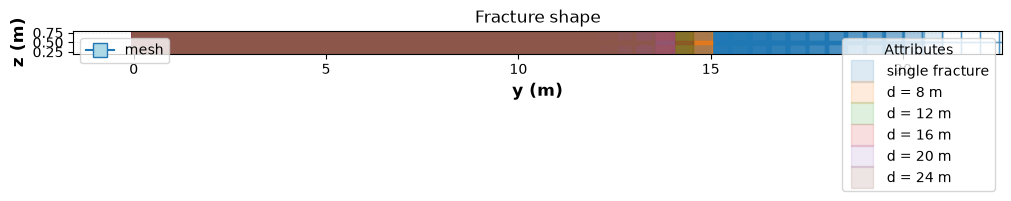

saved: ../figures/kgd_spacing_fracture_shape.png
saved: ../figures/kgd_spacing_length_evolution.png
saved: ../figures/kgd_spacing_height_evolution.png
saved: ../figures/kgd_spacing_aperture_evolution.png
saved: ../figures/kgd_spacing_pressure_evolution.png


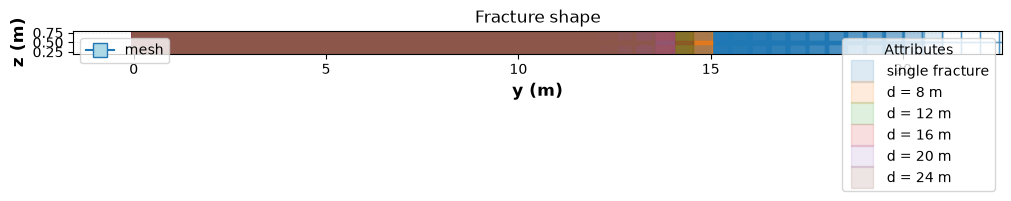

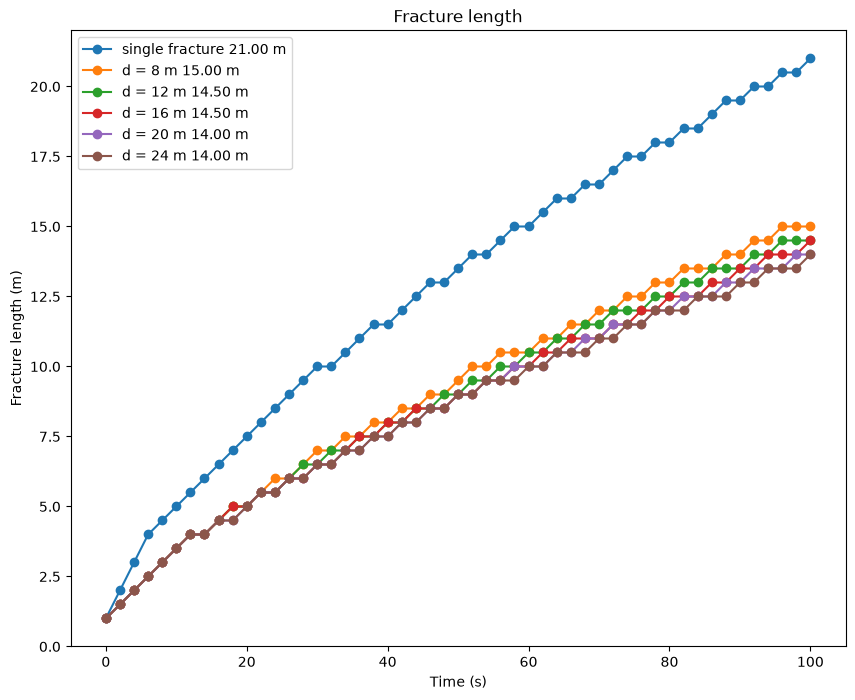

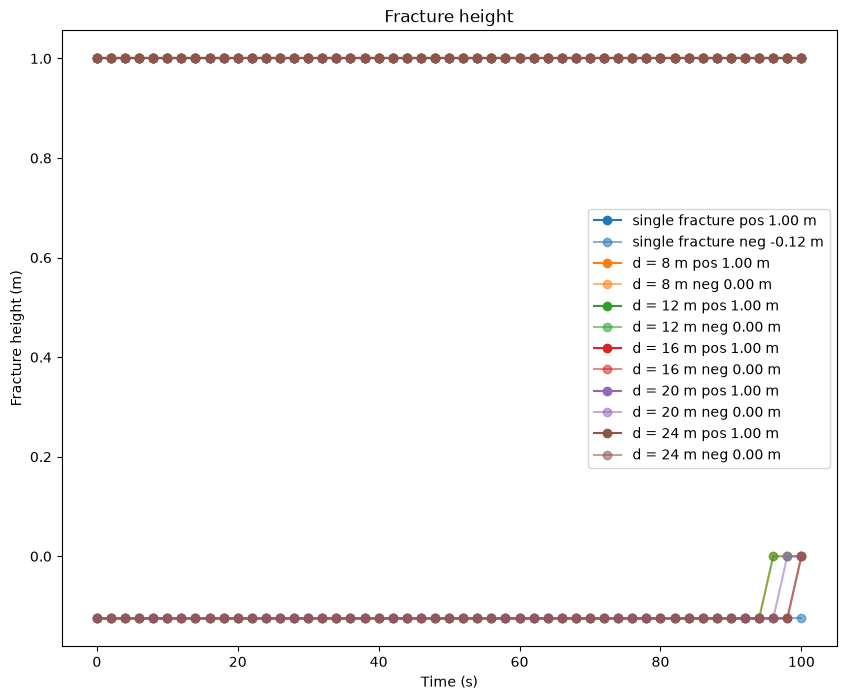

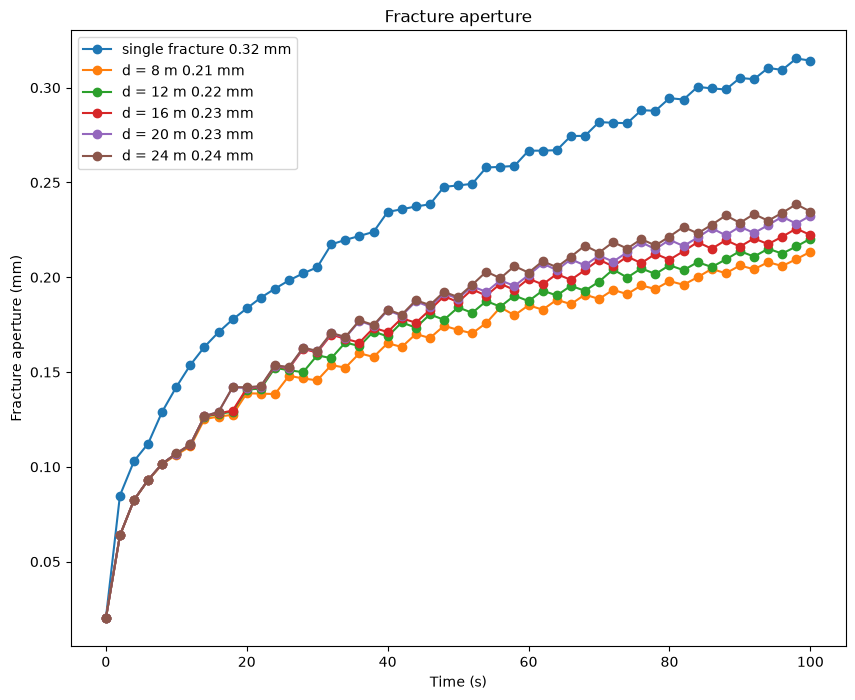

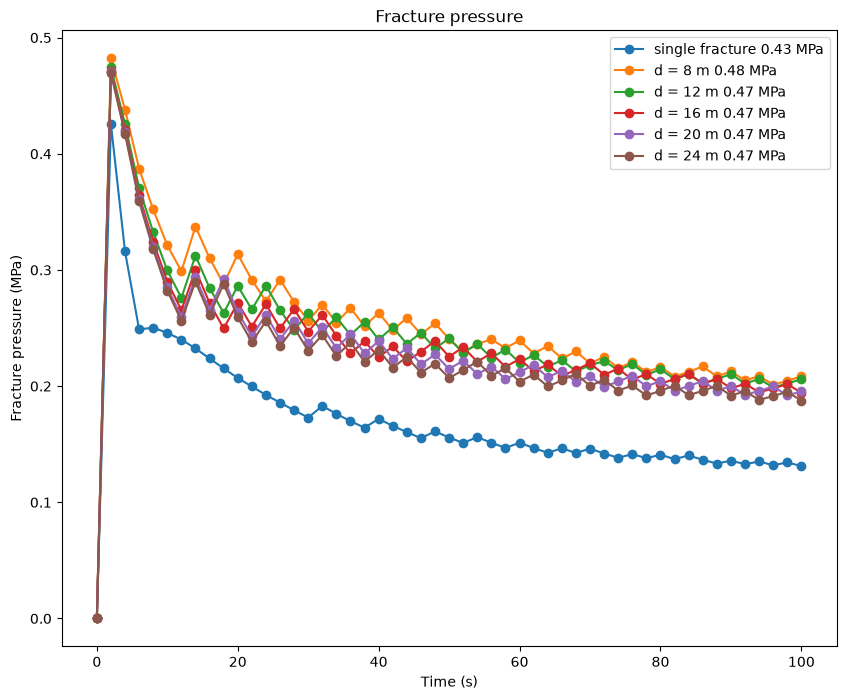

In [21]:
frac_domain = ["y", "z"]

fig, ax = mt.plot_mesh_2d(
    mesh_kgd_spacing,
    position=0,
    plane=f"{frac_domain[0]}{frac_domain[1]}",
    show_polygons_fill=False,
    edge_color=cmap(0),
    alpha=0.3,
    edge_size=1
)

fig_pairs_kgd_spacing, proc_atrb_dict_kgd_spacing = ct.plot_attributes(
    atrb_dict_kgd_spacing,
    frac_domain=frac_domain,
    rename_dict=rename_dict_kgd_spacing,
    frac_mesh=(fig, ax),
    pad=0.03,
    zoom=0.9,
)

for (_f, _), _n in zip(fig_pairs_kgd_spacing,
                       ["kgd_spacing_fracture_shape.png", "kgd_spacing_length_evolution.png",
                        "kgd_spacing_height_evolution.png", "kgd_spacing_aperture_evolution.png",
                        "kgd_spacing_pressure_evolution.png"]):
    save_fig(_f, _n)


kgdToughnessDominated_benchmark_2_const_grid_single_rerun


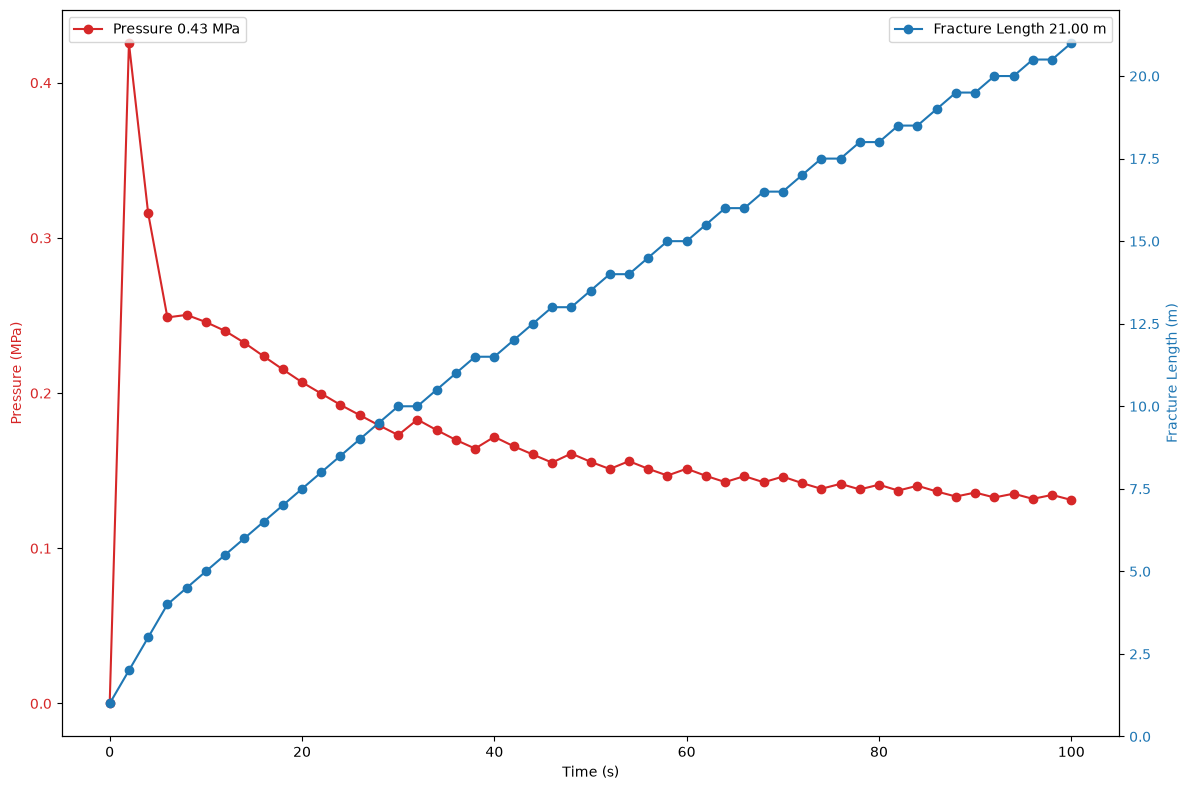

kgdToughnessDominated_benchmark_2_const_grid_8_rerun


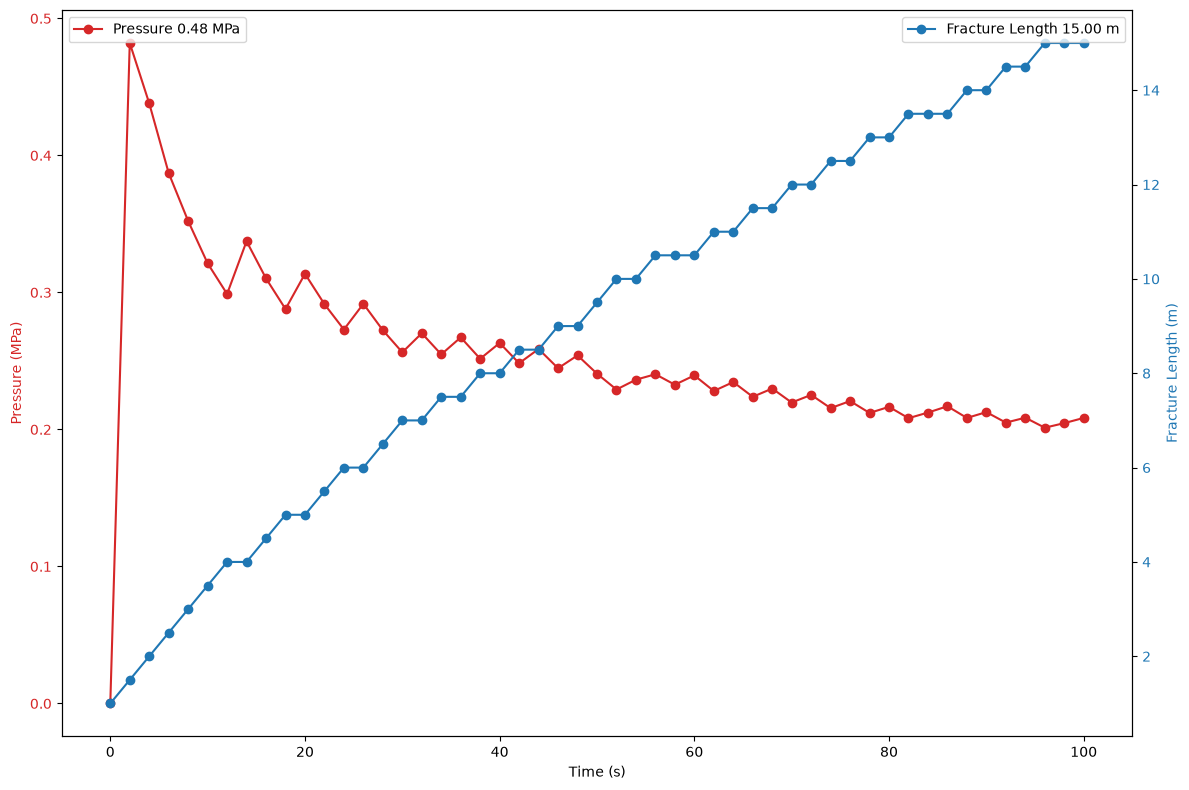

kgdToughnessDominated_benchmark_2_const_grid_12_rerun


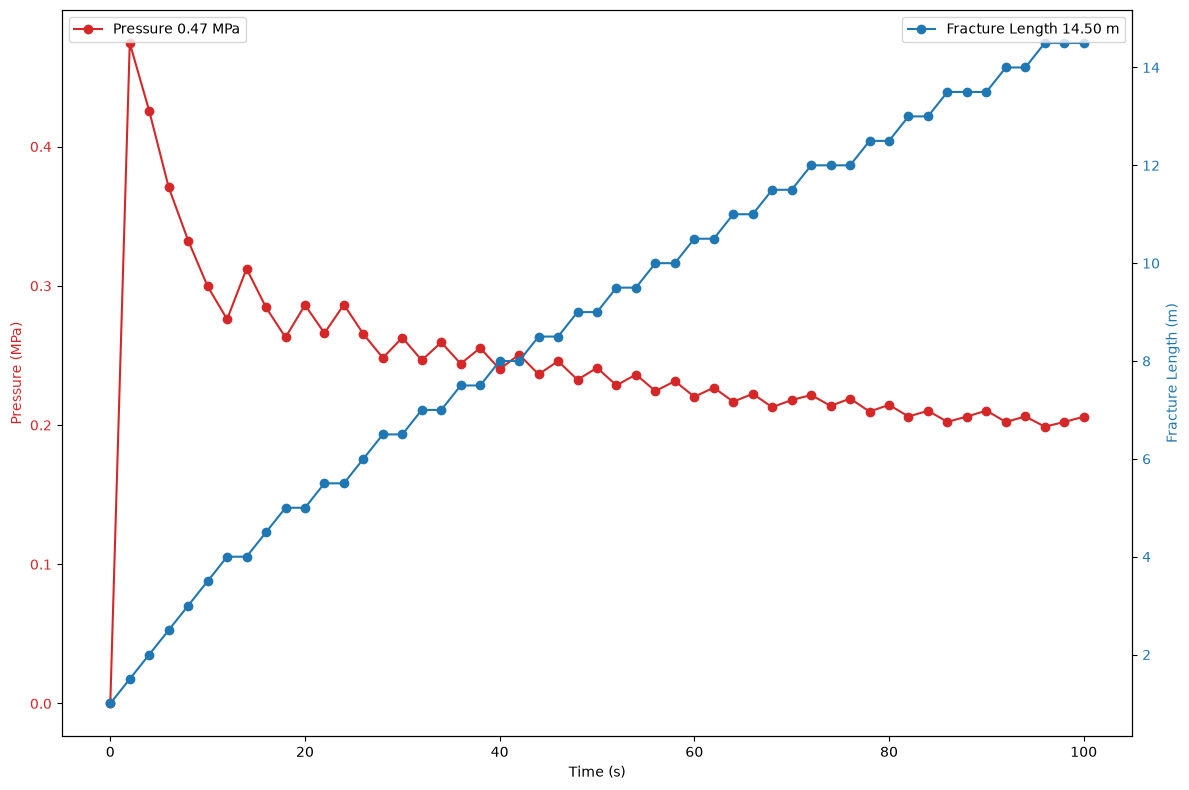

kgdToughnessDominated_benchmark_2_const_grid_16_rerun


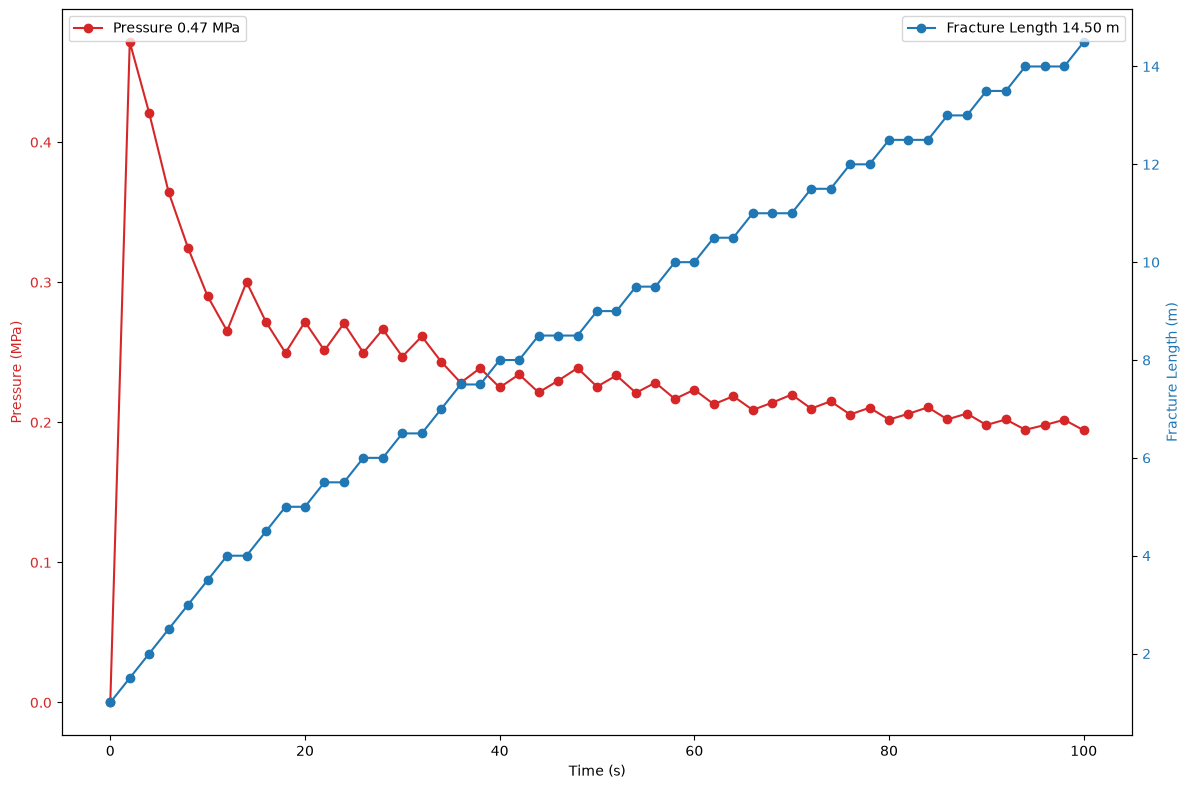

kgdToughnessDominated_benchmark_2_const_grid_20_rerun


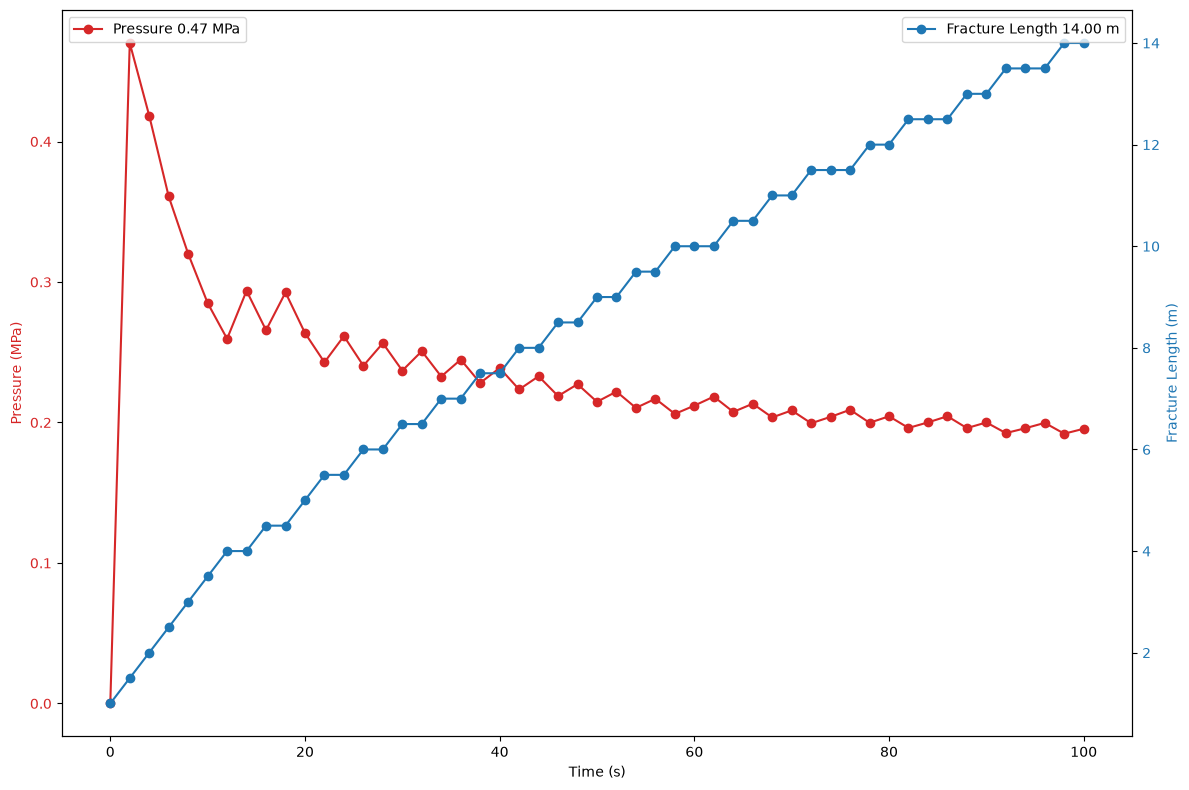

kgdToughnessDominated_benchmark_2_const_grid_24_rerun


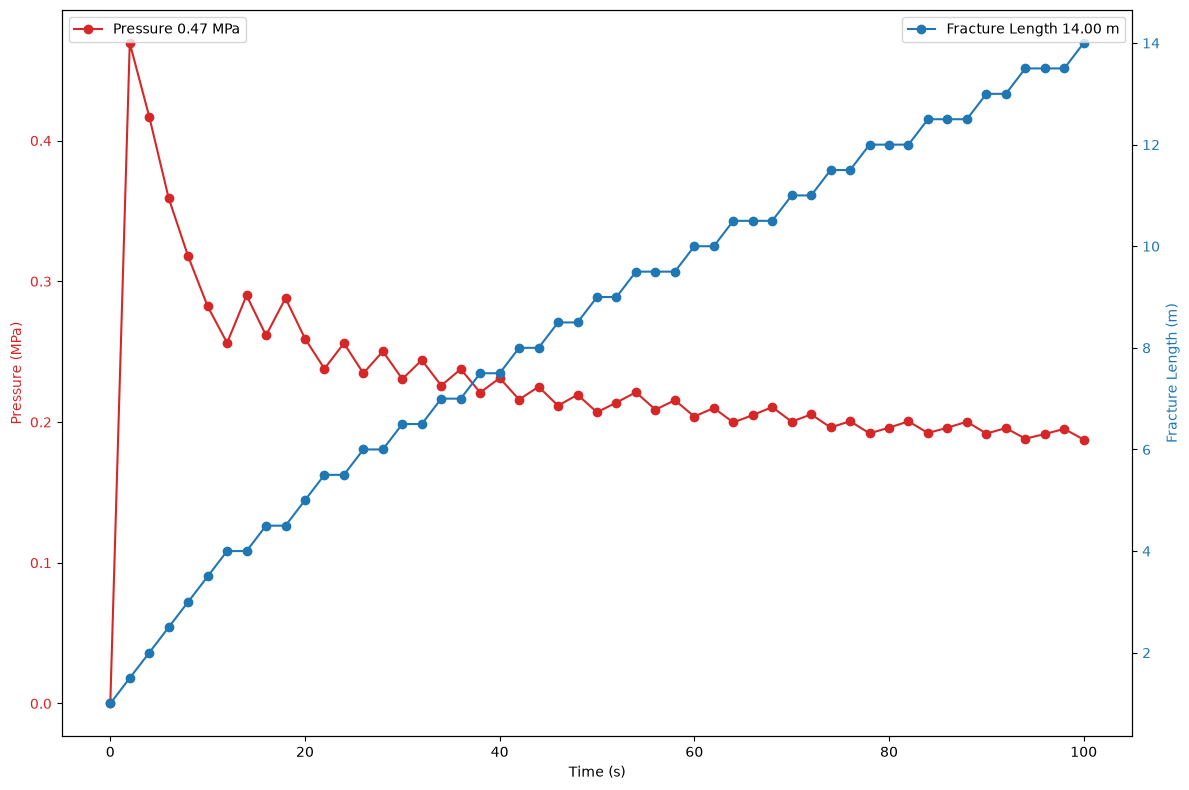

In [22]:
ct.plot_pressure_vs_length(proc_atrb_dict_kgd_spacing, rename_dict_kgd_spacing)

## 2.2 Strain - KGD spacing

In [23]:
strain_dict_kgd_spacing = {}
raw_strain_keys = ["averageStrain", "averageStrain Time", "averageStrain elementCenter"]

for k in raw_data_dict_kgd_spacing.keys():
    if "strain" in k:
        _k = k.split("/")[0]
        print(f"Getting strain for {_k}")
        strain_dict_kgd_spacing[_k] = hdt.get_attributes(raw_data_dict_kgd_spacing[k], raw_strain_keys)

Getting strain for kgdToughnessDominated_benchmark_2_const_grid_12_rerun
Getting strain for kgdToughnessDominated_benchmark_2_const_grid_16_rerun
Getting strain for kgdToughnessDominated_benchmark_2_const_grid_20_rerun
Getting strain for kgdToughnessDominated_benchmark_2_const_grid_24_rerun
Getting strain for kgdToughnessDominated_benchmark_2_const_grid_8_rerun
Getting strain for kgdToughnessDominated_benchmark_2_const_grid_single_rerun


In [24]:
extracted_strain_dict_kgd_spacing = {}

for k, v in strain_dict_kgd_spacing.items():
    print(f"Extracting strain volumes for {k}")
    extracted_strain, (x_vals, y_vals, z_vals) = hdt.get_strain_volumes(
        strain_dict_kgd_spacing[k]["averageStrain"],
        strain_dict_kgd_spacing[k]["elementCenter"],
        comps=["xx", "yy", "zz"],
        show_msgs=False,
        as_volume=True
    )
    extracted_strain_dict_kgd_spacing[k] = extracted_strain, (x_vals, y_vals, z_vals)
    print(f"\tExtracted strain shape: {extracted_strain.shape}")

Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_12_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_16_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_20_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_24_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_8_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_2_const_grid_single_rerun
	Extracted strain shape: (51, 3, 100, 100, 2)


In [25]:
clim = 1e-5   # strain color limit for the KGD sections

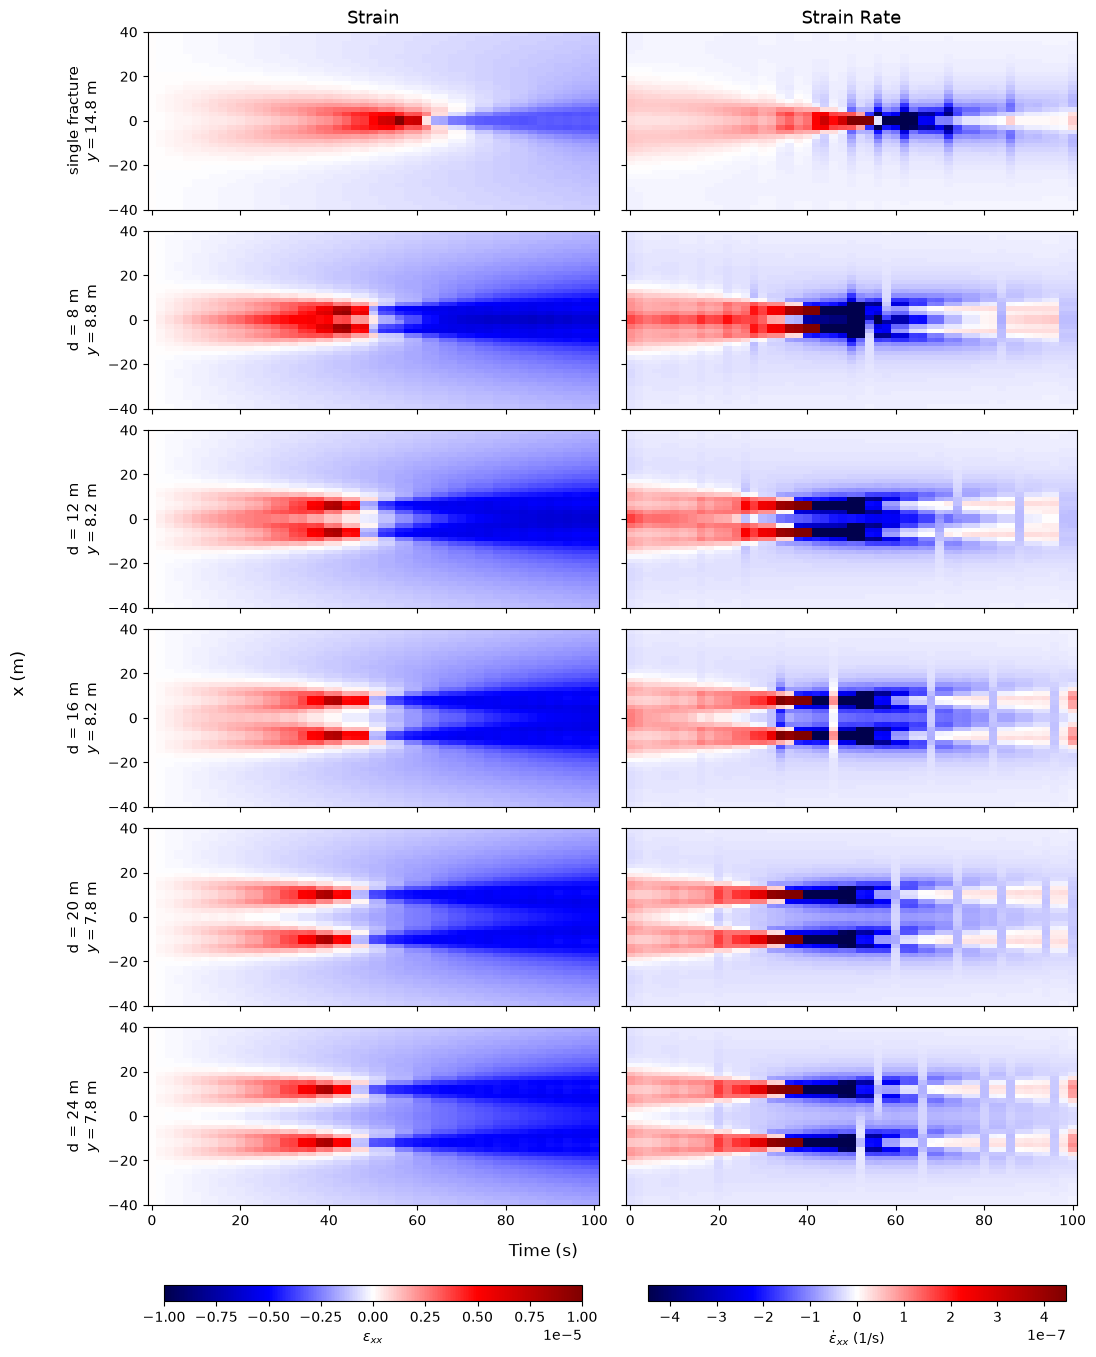

saved: ../figures/kgd_spacing_waterfalls.png


In [26]:
waterfall_dict_kgd_spacing = {}

# one combined grid (rows = runs, cols = strain / strain rate) with shared
# titles, labels, and bottom colorbars (see ct.plot_waterfall_grid)
_entries = []
for k in rename_dict_kgd_spacing.keys():
    extracted_strain = extracted_strain_dict_kgd_spacing[k][0]
    x_vals, y_vals, z_vals = extracted_strain_dict_kgd_spacing[k][1]
    time_axis = strain_dict_kgd_spacing[k]["Time"]
    fl = proc_atrb_dict_kgd_spacing[k]["fracture_length"]

    # monitored line along x at a fixed y near the final fracture length,
    # eps_xx (fracture-normal)
    y_idx = np.argmin(np.abs(y_vals - fl[-1])) - 12
    z_idx = np.argmin(np.abs(z_vals - 0))
    waterfall = extracted_strain[:, 0, :, y_idx, z_idx]
    waterfall_dict_kgd_spacing[k] = waterfall
    _entries.append((f"{rename_dict_kgd_spacing[k]}\n$y = {y_vals[y_idx]:.1f}$ m",
                     waterfall, time_axis, x_vals))

_gfig, _ = ct.plot_waterfall_grid(_entries, clim=clim, ylim=(-40, 40),
                                  comp="xx", offset_label="x (m)")
save_fig(_gfig, "kgd_spacing_waterfalls.png")


# 3. KGD - injection rate

Same KGD geometry, single fracture, injection-rate sweep Q0 ... Q0/16.

## 3.1 Attributes - KGD injection

In [27]:
atrb_dict_kgd_injection = {}

for k in raw_data_dict_kgd_injection.keys():
    if "strain" in k:
        continue
    _k = k.split("/")[0]
    print(f"Getting attributes for {_k}")
    atrb_dict_kgd_injection[_k] = hdt.get_attributes(raw_data_dict_kgd_injection[k])

Getting attributes for kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t
Getting attributes for kgdToughnessDominated_benchmark_spacing_single_inj_half_150t
Getting attributes for kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t
Getting attributes for kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t
Getting attributes for kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t


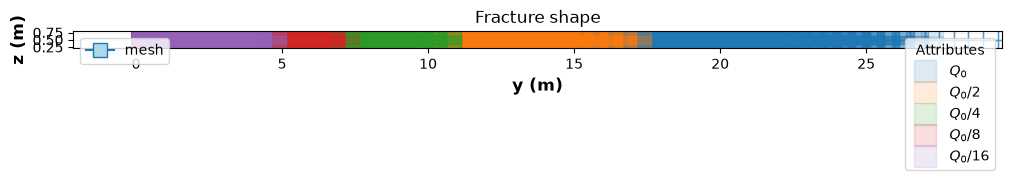

saved: ../figures/kgd_injection_fracture_shape.png
saved: ../figures/kgd_injection_length_evolution.png
saved: ../figures/kgd_injection_height_evolution.png
saved: ../figures/kgd_injection_aperture_evolution.png
saved: ../figures/kgd_injection_pressure_evolution.png


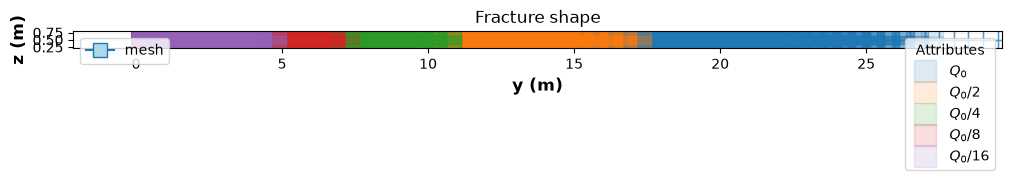

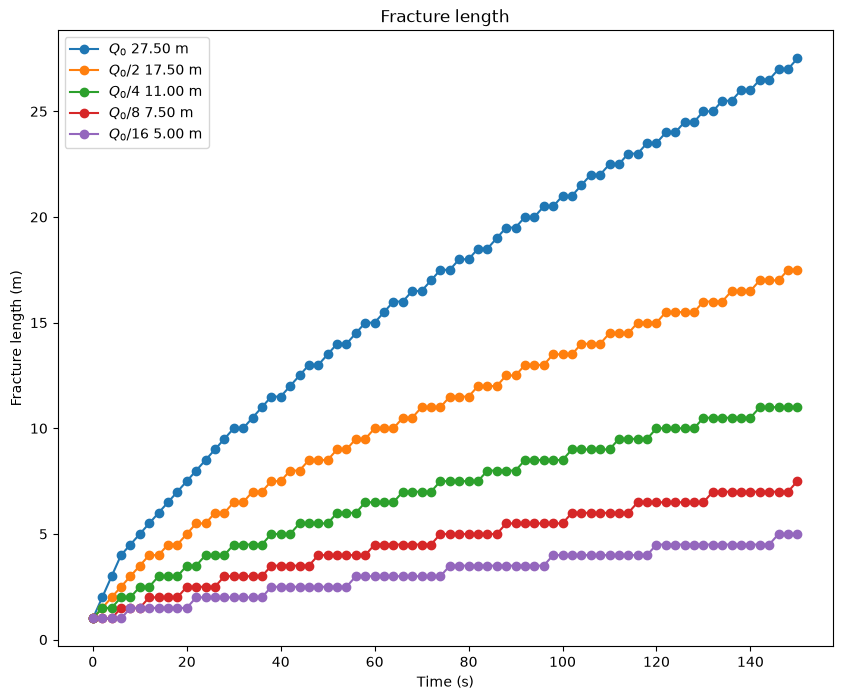

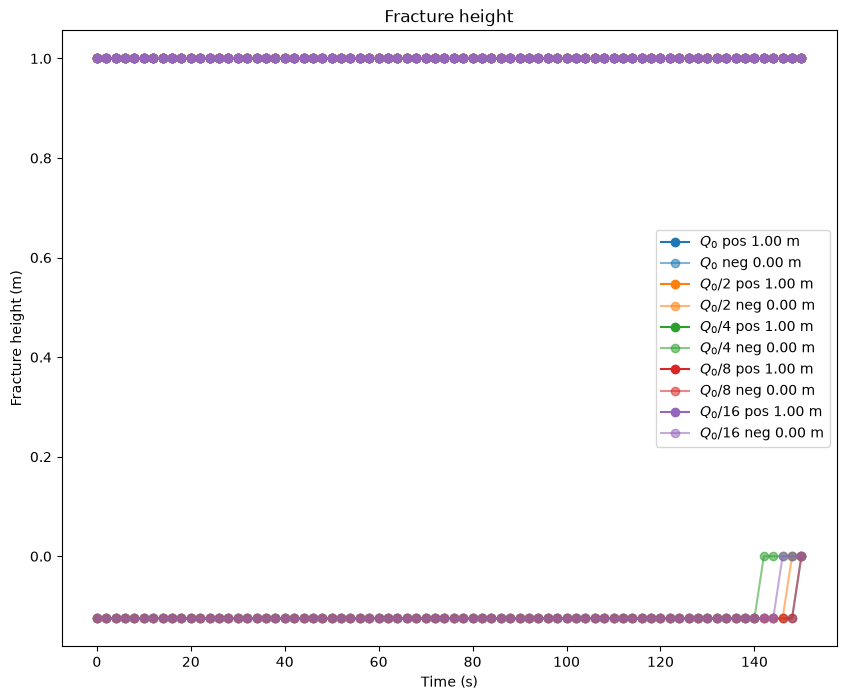

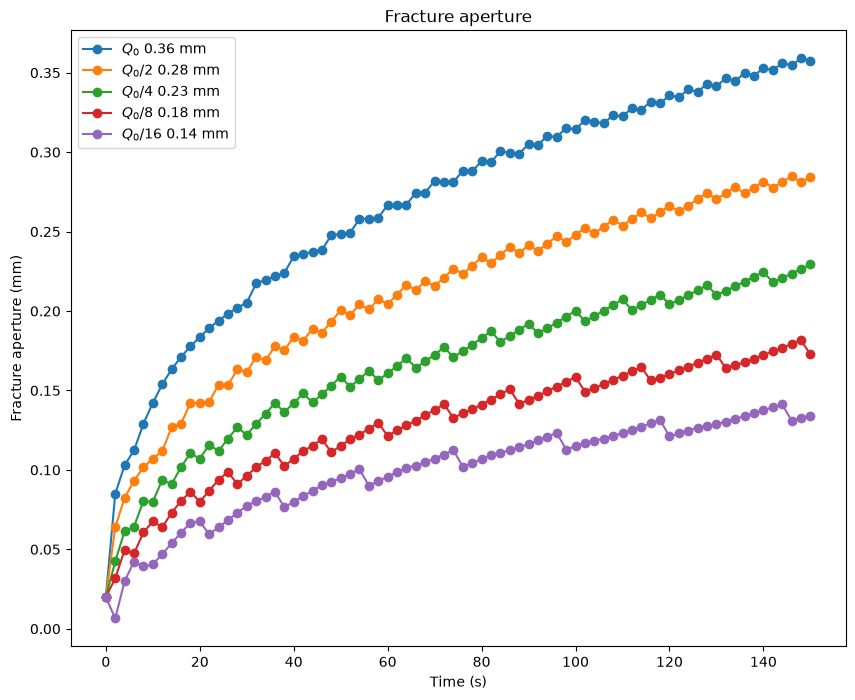

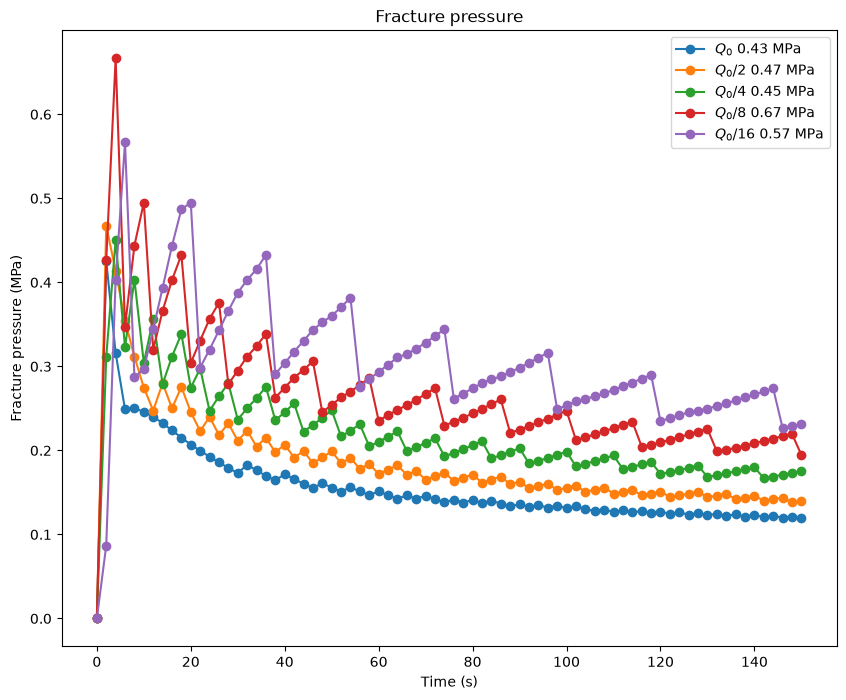

In [28]:
rename_dict_kgd_injection = {
    "kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t": r'$Q_0$',
    "kgdToughnessDominated_benchmark_spacing_single_inj_half_150t": r'$Q_0/2$',
    "kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t": r'$Q_0/4$',
    "kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t": r'$Q_0/8$',
    "kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t": r'$Q_0/16$',
}

frac_domain = ["y", "z"]

fig, ax = mt.plot_mesh_2d(
    mesh_kgd_spacing,   # same mesh as the spacing sweep
    position=0,
    plane=f"{frac_domain[0]}{frac_domain[1]}",
    show_polygons_fill=False,
    edge_color=cmap(0),
    alpha=0.3,
    edge_size=1
)

fig_pairs_kgd_injection, proc_atrb_dict_kgd_injection = ct.plot_attributes(
    atrb_dict_kgd_injection,
    frac_domain=frac_domain,
    rename_dict=rename_dict_kgd_injection,
    frac_mesh=(fig, ax),
    pad=0.03,
    zoom=0.9,
)

for (_f, _), _n in zip(fig_pairs_kgd_injection,
                       ["kgd_injection_fracture_shape.png", "kgd_injection_length_evolution.png",
                        "kgd_injection_height_evolution.png", "kgd_injection_aperture_evolution.png",
                        "kgd_injection_pressure_evolution.png"]):
    save_fig(_f, _n)


kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t


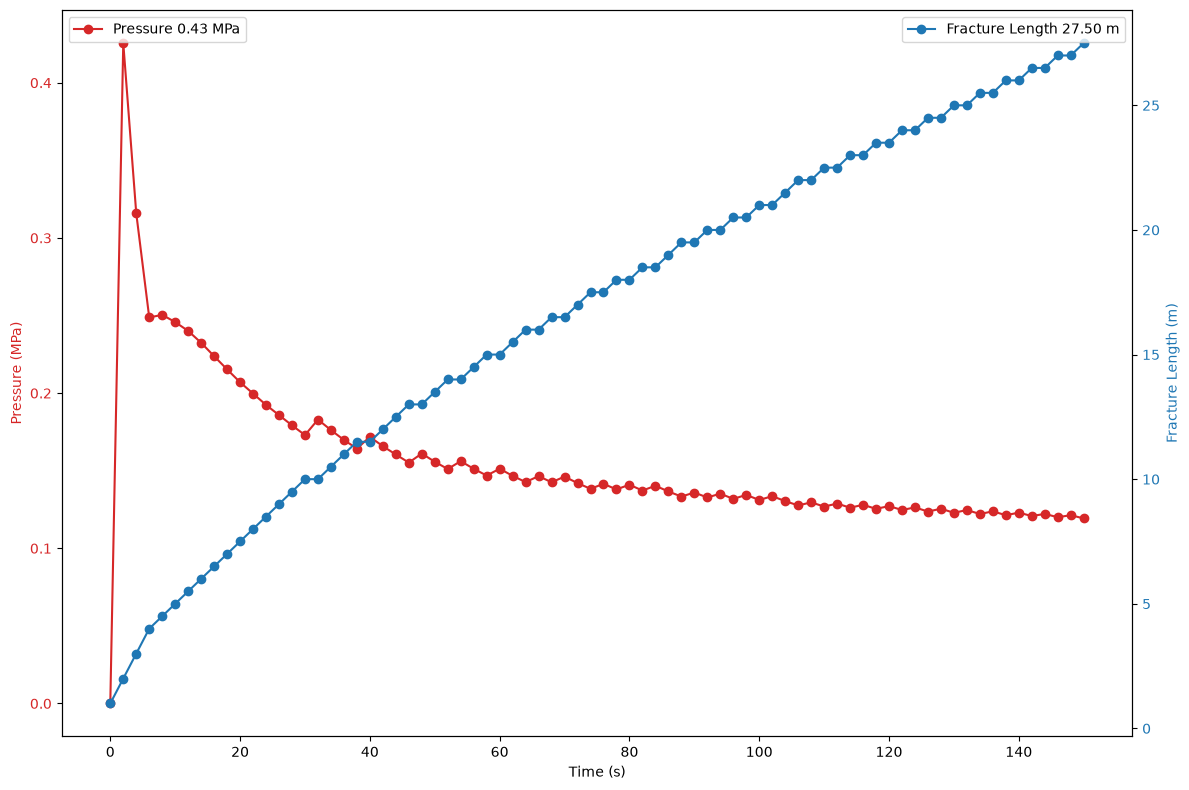

kgdToughnessDominated_benchmark_spacing_single_inj_half_150t


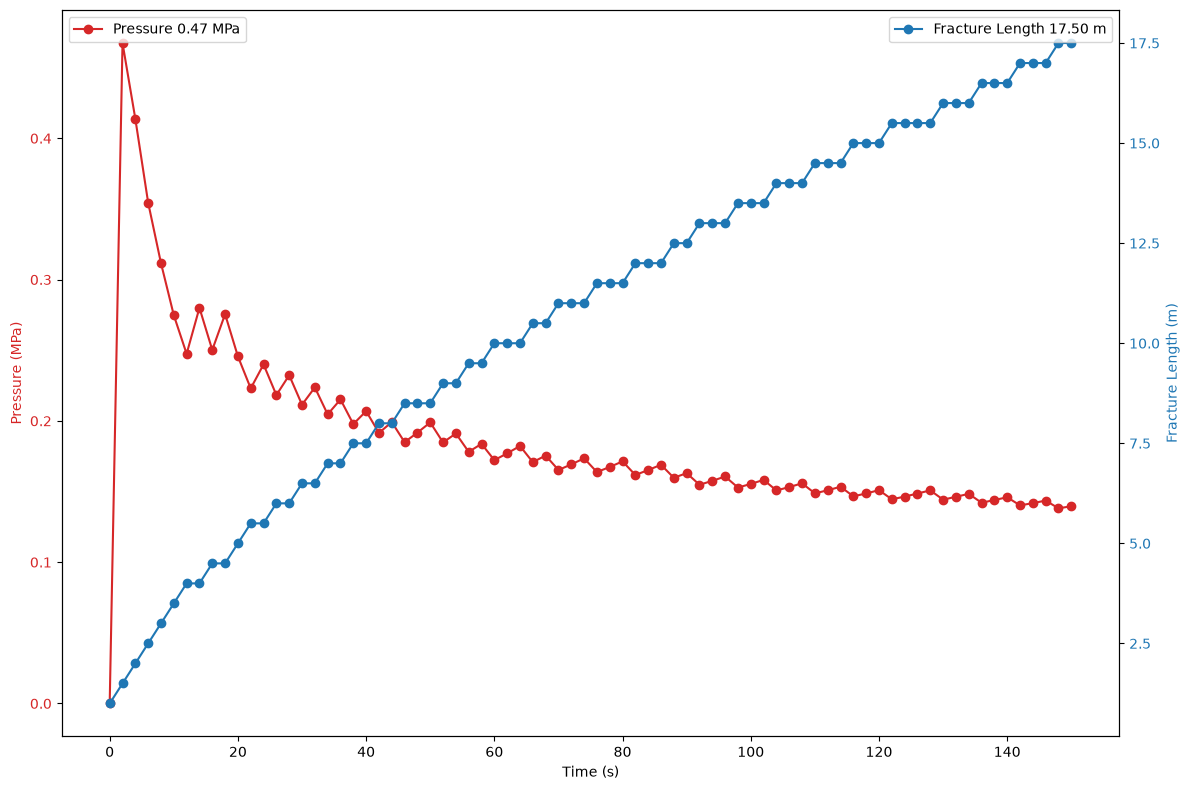

kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t


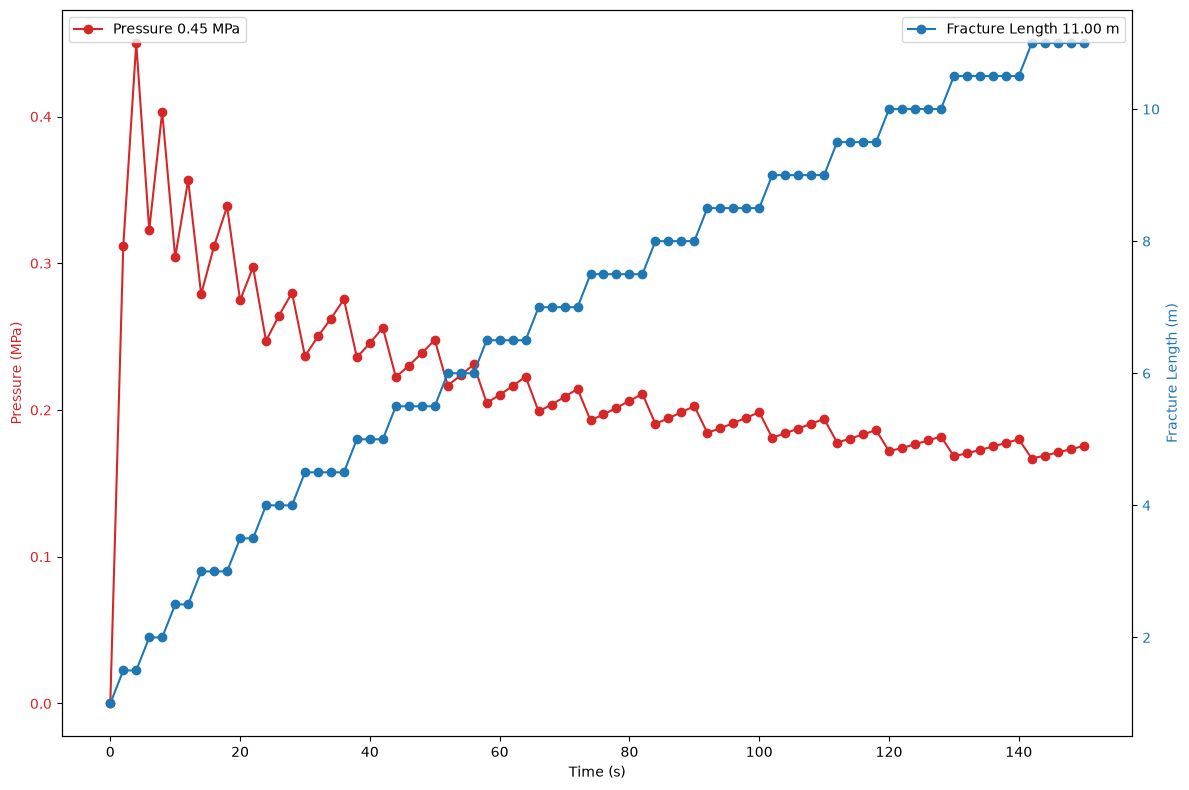

kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t


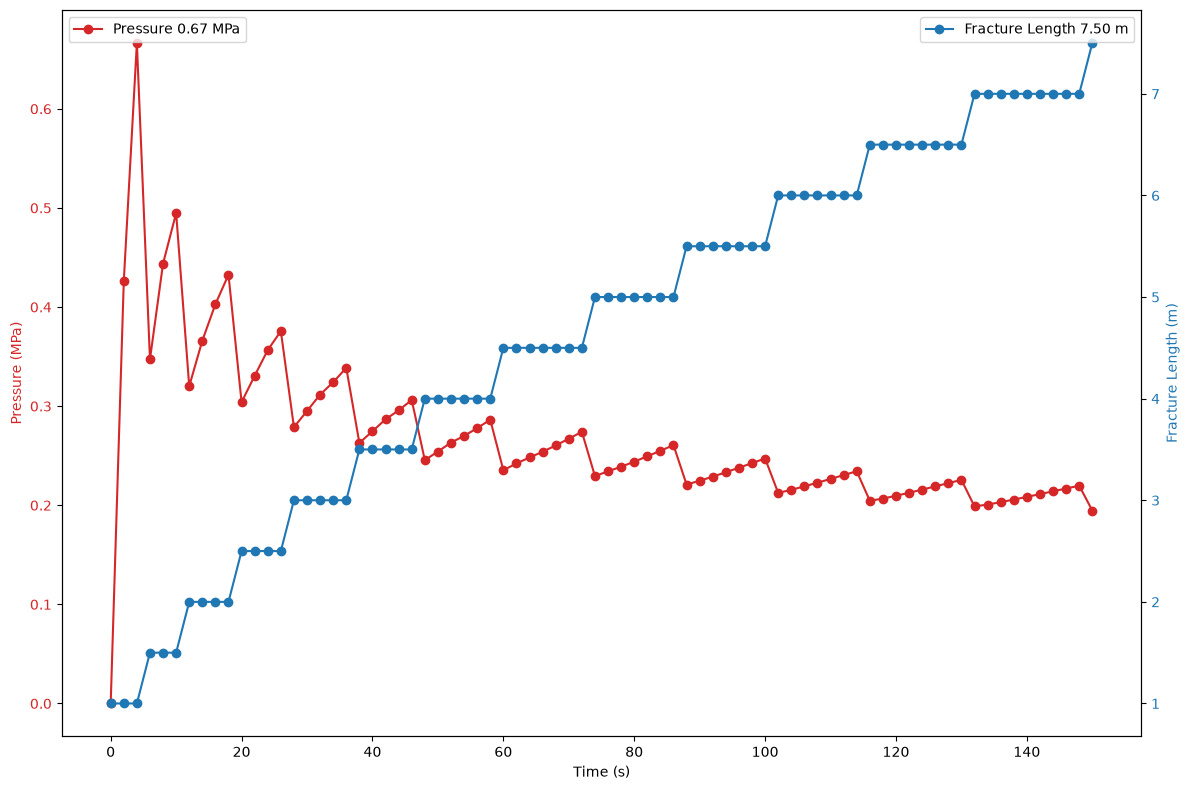

kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t


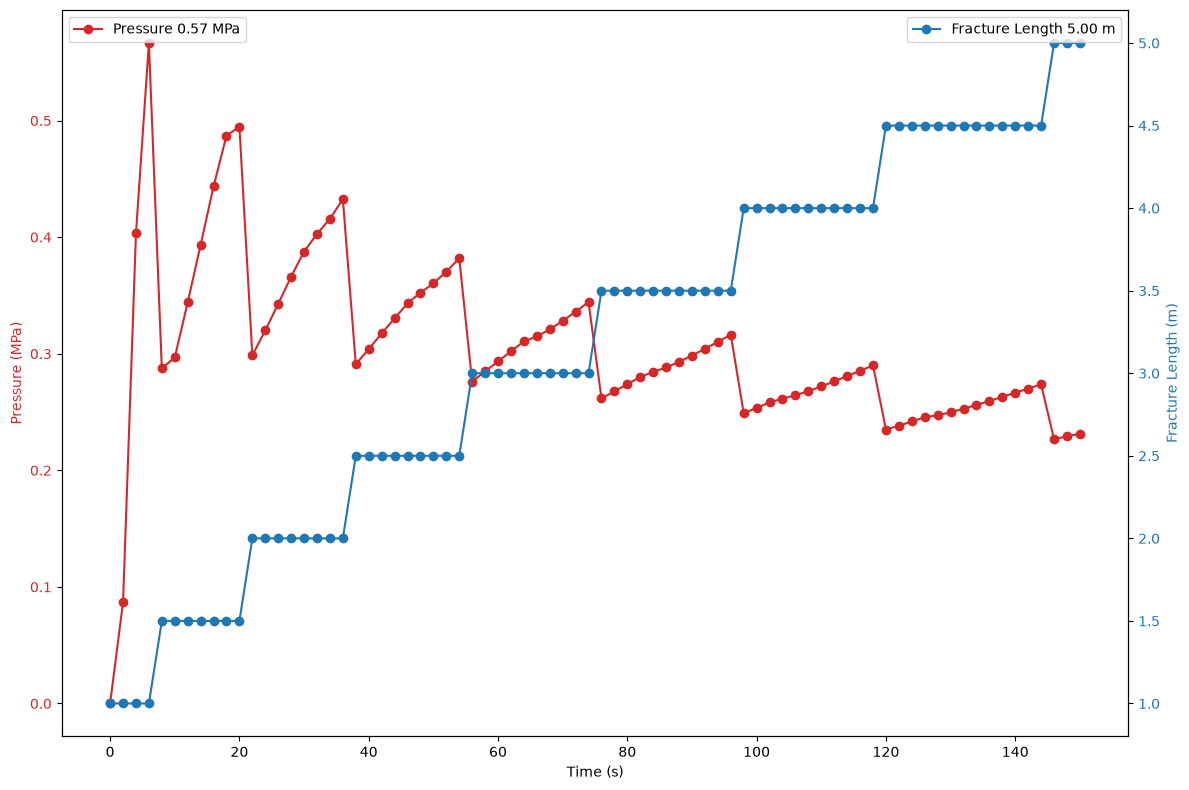

In [29]:
ct.plot_pressure_vs_length(proc_atrb_dict_kgd_injection, rename_dict_kgd_injection)

## 3.2 Strain - KGD injection

In [30]:
strain_dict_kgd_injection = {}
raw_strain_keys = ["averageStrain", "averageStrain Time", "averageStrain elementCenter"]

for k in raw_data_dict_kgd_injection.keys():
    if "strain" in k:
        _k = k.split("/")[0]
        print(f"Getting strain for {_k}")
        strain_dict_kgd_injection[_k] = hdt.get_attributes(raw_data_dict_kgd_injection[k], raw_strain_keys)

Getting strain for kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t
Getting strain for kgdToughnessDominated_benchmark_spacing_single_inj_half_150t
Getting strain for kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t
Getting strain for kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t
Getting strain for kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t


In [31]:
extracted_strain_dict_kgd_injection = {}

for k, v in strain_dict_kgd_injection.items():
    print(f"Extracting strain volumes for {k}")
    extracted_strain, (x_vals, y_vals, z_vals) = hdt.get_strain_volumes(
        strain_dict_kgd_injection[k]["averageStrain"],
        strain_dict_kgd_injection[k]["elementCenter"],
        comps=["xx", "yy", "zz"],
        show_msgs=False,
        as_volume=True
    )
    extracted_strain_dict_kgd_injection[k] = extracted_strain, (x_vals, y_vals, z_vals)
    print(f"\tExtracted strain shape: {extracted_strain.shape}")

Extracting strain volumes for kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t
	Extracted strain shape: (76, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_spacing_single_inj_half_150t
	Extracted strain shape: (76, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t
	Extracted strain shape: (76, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t
	Extracted strain shape: (76, 3, 100, 100, 2)
Extracting strain volumes for kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t
	Extracted strain shape: (76, 3, 100, 100, 2)


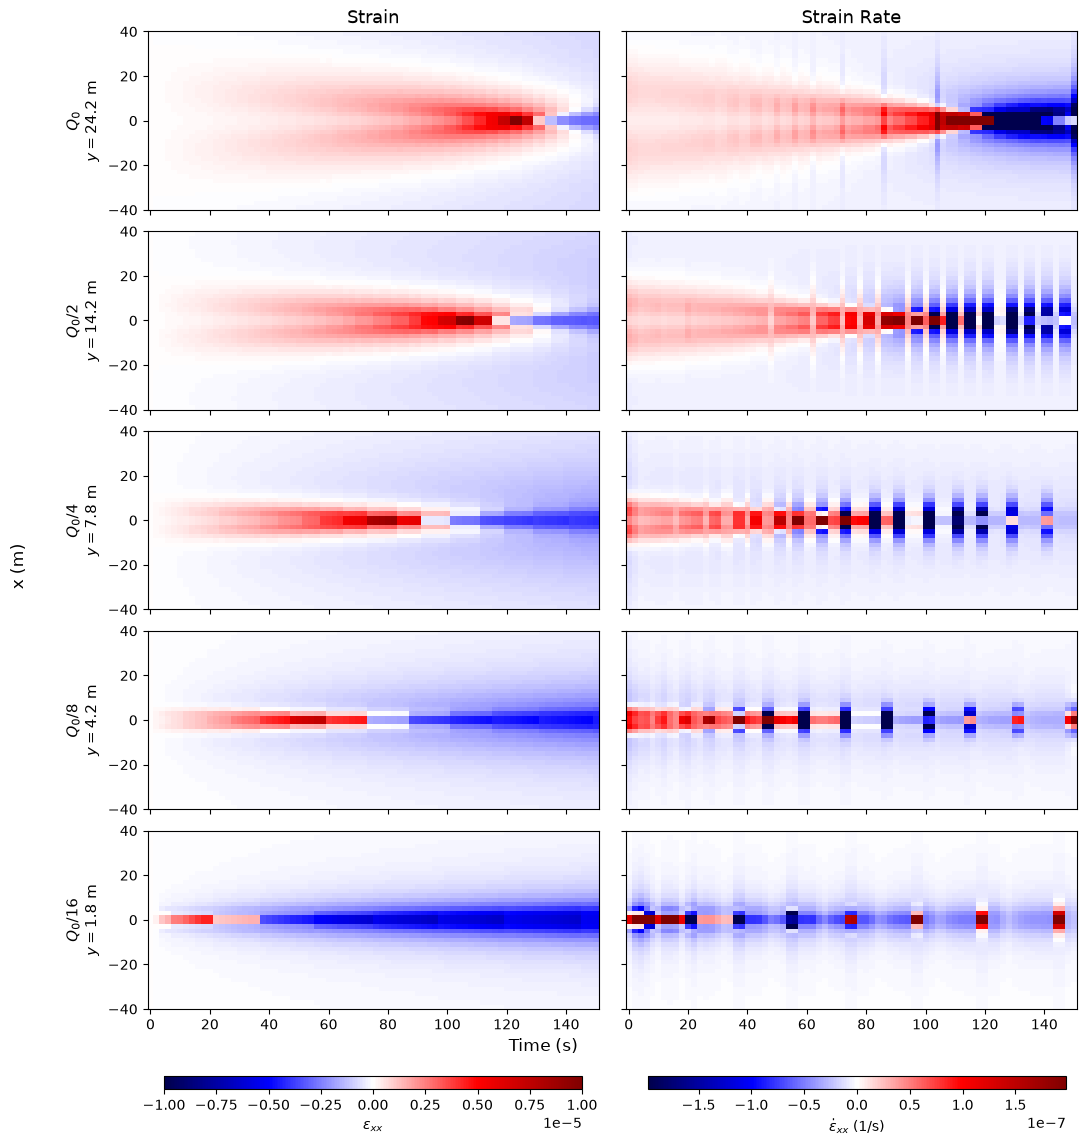

saved: ../figures/kgd_injection_waterfalls.png


In [32]:
waterfall_dict_kgd_injection = {}

# one combined grid (rows = runs, cols = strain / strain rate) with shared
# titles, labels, and bottom colorbars (see ct.plot_waterfall_grid)
_entries = []
for k in rename_dict_kgd_injection.keys():
    extracted_strain = extracted_strain_dict_kgd_injection[k][0]
    x_vals, y_vals, z_vals = extracted_strain_dict_kgd_injection[k][1]
    time_axis = strain_dict_kgd_injection[k]["Time"]
    fl = proc_atrb_dict_kgd_injection[k]["fracture_length"]

    # monitored line along x at a fixed y near the final fracture length,
    # eps_xx (fracture-normal)
    y_idx = np.argmin(np.abs(y_vals - fl[-1])) - 6
    z_idx = np.argmin(np.abs(z_vals - 0))
    waterfall = extracted_strain[:, 0, :, y_idx, z_idx]
    waterfall_dict_kgd_injection[k] = waterfall
    _entries.append((f"{rename_dict_kgd_injection[k]}\n$y = {y_vals[y_idx]:.1f}$ m",
                     waterfall, time_axis, x_vals))

_gfig, _ = ct.plot_waterfall_grid(_entries, clim=clim, ylim=(-40, 40),
                                  comp="xx", offset_label="x (m)")
save_fig(_gfig, "kgd_injection_waterfalls.png")
